### Group I Members


| No. | Name                      | Registration Number | Student Number |
|-----|---------------------------|---------------------|----------------|
| 1   | Kajjabwangu Joseph Lester | 24/U/05090/PS       | 2400705090     |
| 2   | Atim Reina Michal         | 24/U/03845/PS       | 2400703845     |
| 3   | Mwanje Simon Peter        | 24/U/07633/PS       | 2400707633     |
| 4   | Mutebi Kennedy            | 24/U/07472/PS       | 2400707472     |
| 5   | Lutwama Kenneth           | 24/U/06539/PS       | 2400706539     |

# NETWORK INTRUSION DETECTION SYSTEM (IDS)
- **Dataset:** UNSW-NB15(both training and testing set)
- **Approach:** Dual-Phase that contains both Unsupervised Anomaly Detection and  Supervised Classification


## 1. Problem Definition

Modern networks connect a vast number of systems — servers, workstations, databases, and cloud infrastructure — making them a constant target for malicious actors. As network environments grow in complexity, so does the attack surface, making effective intrusion detection a critical component of any security strategy.

Traditional signature-based Intrusion Detection Systems (IDS) match incoming traffic against a known library of attack signatures. While effective for known threats, they completely fail against novel, zero-day attacks. **Anomaly-based IDS** overcomes this by learning normal traffic behaviour and flagging deviations — making it capable of detecting previously unseen attacks.

**Can machine learning models — both with and without labelled attack data - accurately identify malicious network traffic, and how do the two approaches compare in detection performance?**

### Why a Dual-Phase Approach?
In real network deployments, labelled attack data is rarely available immediately. This project therefore implements two phases:

1. **Supervised Phase** — models are trained WITH labels, simulating a mature deployment where historical attacks have been catalogued
2. **Unsupervised Phase** — models are trained with NO labels, simulating a fresh deployment where no attack history exists
- **Comparative Analysis** — both phases are evaluated against the true labels to measure the cost of not having labels


### Models/Methods Selected
| Model/Method | Phase | Type | Justification |
|---|---|---|---|
| **Decision Tree** | Supervised | Tree-based | Interpretable baseline; reveals human-readable detection rules |
| **Random Forest** | Supervised | Ensemble | High accuracy; provides feature importance |
| **Isolation Forest** | Unsupervised | Ensemble / Tree-based | Scalable, handles high-dimensional traffic data |
| **DBSCAN** | Unsupervised | Density-based Clustering | Detects anomalies as low-density outliers |
| **Autoencoder** | Unsupervised | Deep Learning | Learns compressed normal traffic; flags high reconstruction error |


###  Dataset: UNSW-NB15
The UNSW-NB15 dataset was created by the Australian Centre for Cyber Security (ACCS) using the IXIA PerfectStorm tool to generate realistic network traffic. It contains 49 features capturing network connection properties, and includes both normal traffic and 9 categories of modern attacks — making it highly relevant for contemporary network security research.


## 2. Data Collection

### About the UNSW-NB15 Dataset
The UNSW-NB15 dataset was generated in 2015 at the Cyber Range Lab of the Australian Centre for Cyber Security. Unlike older datasets such as KDD Cup 99, UNSW-NB15 captures **modern attack patterns** relevant to today's Network threat landscape.

**Key properties:**
- 49 network traffic features (basic, content, time, additional categories)
- Binary label: `label` (0 = normal, 1 = attack)
- Multi-class label: `attack_cat` (specific attack category)
- Pre-split into training and test CSV files

### Attack Categories in UNSW-NB15
| Attack Category | Description |
|---|---|
| **Normal** | Legitimate network traffic |
| **Fuzzers** | Attempts to crash a program by feeding random data |
| **Analysis** | Port scans and spam attacks |
| **Backdoors** | Secret access methods bypassing authentication |
| **DoS** | Denial of Service — overwhelming a target |
| **Exploits** | Known vulnerability exploitation |
| **Generic** | Attacks against block cipher algorithms |
| **Reconnaissance** | Information gathering / network probing |
| **Shellcode** | Small code pieces used to exploit vulnerabilities |
| **Worms** | Self-replicating malware that spreads across networks |

###  Feature Categories
| Category | Example Features | Description |
|---|---|---|
| **Basic** | `dur`, `proto`, `service`, `state`, `sbytes`, `dbytes` | Core connection properties |
| **Content** | `shttp_mthd`, `is_ftp_login`, `ct_ftp_cmd` | Payload and application-layer features |
| **Time** | `stcpb`, `dtcpb`, `tcprtt`, `synack`, `ackdat` | TCP timing and sequence features |
| **Additional** | `ct_srv_src`, `ct_dst_ltm`, `ct_src_dport_ltm` | Statistical connection count features |

### Why UNSW-NB15?
UNSW-NB15 captures realistic TCP/UDP/ICMP protocol traffic across a wide range of modern attack categories — particularly Backdoors, Worms, and Exploits — which closely mirror the threats seen in real-world network breaches. The dataset is widely cited in recent IDS research, making results directly comparable to published benchmarks.

In [376]:
import sys
!{sys.executable} -m pip install tensorflow scikit-learn pandas numpy matplotlib seaborn --quiet
print("All libraries installed.")


[notice] A new release of pip is available: 24.3.1 -> 26.1.2
[notice] To update, run: pip3 install --upgrade pip
All libraries installed.


### Importing necessary Libraries

In [377]:
# Data handling
import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split

# Unsupervised models
from sklearn.ensemble import IsolationForest
from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA

# Supervised models
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text

# Evaluation
from sklearn.metrics import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, silhouette_score,
    accuracy_score, precision_score, recall_score, f1_score, precision_recall_curve, average_precision_score, roc_curve, auc
)

# Deep learning
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

import time
import warnings
warnings.filterwarnings('ignore')

print(" All libraries imported successfully.")

 All libraries imported successfully.


###  Loading the Dataset (Both the training and testing splits)
We load both the training and test CSV files provided with the UNSW-NB15 dataset.
> **Made sure** `UNSW_NB15_training-set.csv` and `UNSW_NB15_testing-set.csv` are in the **same folder as the notebook.**

In [378]:
import os

BASE_DIR = os.getcwd()

train_path = os.path.join(BASE_DIR, 'UNSW_NB15_training-set.csv')
test_path  = os.path.join(BASE_DIR, 'UNSW_NB15_testing-set.csv')

print("Looking for files in:", BASE_DIR)
print("Train exists:", os.path.exists(train_path))
print("Test exists: ", os.path.exists(test_path))

train_df = pd.read_csv(train_path)
test_df  = pd.read_csv(test_path)

df = pd.concat([train_df, test_df], ignore_index=True)
print(f"\nLoaded successfully! Shape: {df.shape}")
df.head()

Looking for files in: /Users/reinamichal/Desktop/Group I Machine learning (IDS)/Network-Intrusion-detection-Machine-learning
Train exists: True
Test exists:  True

Loaded successfully! Shape: (257673, 45)


,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,1,0.000011,udp,-,INT,2,0,496,0,90909.0902,...,1,2,0,0,0,1,2,0,Normal,0
1,2,0.000008,udp,-,INT,2,0,1762,0,125000.0003,...,1,2,0,0,0,1,2,0,Normal,0
2,3,0.000005,udp,-,INT,2,0,1068,0,200000.0051,...,1,3,0,0,0,1,3,0,Normal,0
3,4,0.000006,udp,-,INT,2,0,900,0,166666.6608,...,1,3,0,0,0,2,3,0,Normal,0
4,5,0.000010,udp,-,INT,2,0,2126,0,100000.0025,...,1,3,0,0,0,2,3,0,Normal,0


In [379]:

# Load training and test sets
train_df = pd.read_csv(train_path)
test_df  = pd.read_csv(test_path)


df = pd.concat([train_df, test_df], ignore_index=True)

print(f"Training set:  {train_df.shape[0]:,} rows × {train_df.shape[1]} columns")
print(f"Test set:      {test_df.shape[0]:,} rows × {test_df.shape[1]} columns")
print(f"Combined:      {df.shape[0]:,} rows × {df.shape[1]} columns")
df.head()

Training set:  82,332 rows × 45 columns
Test set:      175,341 rows × 45 columns
Combined:      257,673 rows × 45 columns


,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,1,0.000011,udp,-,INT,2,0,496,0,90909.0902,...,1,2,0,0,0,1,2,0,Normal,0
1,2,0.000008,udp,-,INT,2,0,1762,0,125000.0003,...,1,2,0,0,0,1,2,0,Normal,0
2,3,0.000005,udp,-,INT,2,0,1068,0,200000.0051,...,1,3,0,0,0,1,3,0,Normal,0
3,4,0.000006,udp,-,INT,2,0,900,0,166666.6608,...,1,3,0,0,0,2,3,0,Normal,0
4,5,0.000010,udp,-,INT,2,0,2126,0,100000.0025,...,1,3,0,0,0,2,3,0,Normal,0


In [380]:

print("Columns in dataset:")
print(df.columns.tolist())
print(f"\n'label' column present:      {'label' in df.columns}")
print(f"'attack_cat' column present:  {'attack_cat' in df.columns}")

Columns in dataset:
['id', 'dur', 'proto', 'service', 'state', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sttl', 'dttl', 'sload', 'dload', 'sloss', 'dloss', 'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'dwin', 'tcprtt', 'synack', 'ackdat', 'smean', 'dmean', 'trans_depth', 'response_body_len', 'ct_srv_src', 'ct_state_ttl', 'ct_dst_ltm', 'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm', 'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd', 'ct_src_ltm', 'ct_srv_dst', 'is_sm_ips_ports', 'attack_cat', 'label']

'label' column present:      True
'attack_cat' column present:  True


In [381]:
# Label distribution
print("\nBinary Label Distribution:")
print(df['label'].value_counts())
print(f"\nAttack Category Distribution:")
print(df['attack_cat'].value_counts())


Binary Label Distribution:
label
1    164673
0     93000
Name: count, dtype: int64

Attack Category Distribution:
attack_cat
Normal            93000
Generic           58871
Exploits          44525
Fuzzers           24246
DoS               16353
Reconnaissance    13987
Analysis           2677
Backdoor           2329
Shellcode          1511
Worms               174
Name: count, dtype: int64



## 3. Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) is the process of systematically investigating the dataset before modelling. In an IDS context, EDA helps us understand what normal traffic looks like, how attack traffic differs, and which features are likely to be most informative for detection. Every visualisation and statistic here directly informs decisions made in preprocessing and modelling.


In [382]:
print(f"Dataset shape: {df.shape}")
print(f"\n Data Types")
print(df.dtypes.value_counts())
print(f"\nCategorical columns: {df.select_dtypes(include='object').columns.tolist()}")
print(f"Numeric columns:     {len(df.select_dtypes(include=np.number).columns)}")

Dataset shape: (257673, 45)

 Data Types
int64      30
float64    11
object      4
Name: count, dtype: int64

Categorical columns: ['proto', 'service', 'state', 'attack_cat']
Numeric columns:     41



 UNSW-NB15 Dataset — Full Feature Dictionary

| # | Feature | Full Name | Description |
|---|---|---|---|
| 1 | `dur` | Duration | Record total duration of the connection |
| 2 | `proto` | Protocol | Transaction protocol (e.g. tcp, udp, icmp) |
| 3 | `service` | Service | Network service (e.g. http, ftp, smtp) |
| 4 | `state` | State | Connection state and its dependent protocol (e.g. FIN, CON) |
| 5 | `spkts` | Source Packets | Number of packets sent by the source |
| 6 | `dpkts` | Destination Packets | Number of packets sent by the destination |
| 7 | `sbytes` | Source Bytes | Number of bytes sent by the source |
| 8 | `dbytes` | Destination Bytes | Number of bytes sent by the destination |
| 9 | `rate` | Rate | Transfer rate of the connection |
| 10 | `sttl` | Source TTL | Source to destination time-to-live value |
| 11 | `dttl` | Destination TTL | Destination to source time-to-live value |
| 12 | `sload` | Source Load | Source bits per second |
| 13 | `dload` | Destination Load | Destination bits per second |
| 14 | `sloss` | Source Loss | Source packets retransmitted or dropped |
| 15 | `dloss` | Destination Loss | Destination packets retransmitted or dropped |
| 16 | `sinpkt` | Source Inter-Packet | Source inter-packet arrival time in milliseconds |
| 17 | `dinpkt` | Destination Inter-Packet | Destination inter-packet arrival time in milliseconds |
| 18 | `sjit` | Source Jitter | Source jitter (variation in packet delay) |
| 19 | `djit` | Destination Jitter | Destination jitter |
| 20 | `swin` | Source Window | Source TCP window advertisement value |
| 21 | `stcpb` | Source TCP Base | Source TCP base sequence number |
| 22 | `dtcpb` | Destination TCP Base | Destination TCP base sequence number |
| 23 | `dwin` | Destination Window | Destination TCP window advertisement value |
| 24 | `tcprtt` | TCP RTT | TCP connection setup round-trip time (synack + ackdat) |
| 25 | `synack` | SYN-ACK Time | Time between SYN and SYN-ACK packets |
| 26 | `ackdat` | ACK-Data Time | Time between SYN-ACK and ACK packets |
| 27 | `smean` | Source Mean | Mean of the packet size sent by the source |
| 28 | `dmean` | Destination Mean | Mean of the packet size sent by the destination |
| 29 | `trans_depth` | Transaction Depth | Pipelined depth of associated connection to HTTP |
| 30 | `response_body_len` | Response Body Length | Actual uncompressed content size of HTTP data |
| 31 | `ct_srv_src` | Count Service+Source | No. of connections with same service and source in 100 records |
| 32 | `ct_state_ttl` | Count State+TTL | No. of connections with same state and TTL in 100 records |
| 33 | `ct_dst_ltm` | Count Destination (Time) | No. of connections to same destination in 100 records |
| 34 | `ct_src_dport_ltm` | Count Source+Dest Port (Time) | No. of connections from same source to same dest port |
| 35 | `ct_dst_sport_ltm` | Count Dest+Source Port (Time) | No. of connections to same destination from same source port |
| 36 | `ct_dst_src_ltm` | Count Dest+Source (Time) | No. of connections between same source and destination |
| 37 | `is_ftp_login` | FTP Login Flag | 1 if FTP session accessed with user and password |
| 38 | `ct_ftp_cmd` | FTP Command Count | No. of FTP commands in an FTP session |
| 39 | `ct_flw_http_mthd` | HTTP Method Count | No. of flows with methods GET and POST in HTTP |
| 40 | `ct_src_ltm` | Count Source (Time) | No. of connections from same source in 100 records |
| 41 | `ct_srv_dst` | Count Service+Dest | No. of connections with same service and destination |
| 42 | `is_sm_ips_ports` | Same IP/Port Flag | 1 if source and destination IPs and ports are equal |
| 43 | `attack_cat` | Attack Category | Specific attack type (Normal, DoS, Exploits, etc.) |
| 44 | `label` | Label | Binary label: 0 = Normal traffic, 1 = Attack traffic |


In [383]:
# Missing values — must be handled before training
print("Missing Values")
missing = df.isnull().sum()
missing = missing[missing > 0]
if len(missing) > 0:
    print(missing)
    print(f"\nTotal missing cells: {missing.sum():,}")
else:
    print(" No missing values found.")

Missing Values
 No missing values found.


In [384]:
# Duplicate records
dupes = df.duplicated().sum()
print(f"Duplicate rows: {dupes:,}")
if dupes > 0:
    pct = dupes / len(df) * 100
    print(f"That is {pct:.2f}% of the dataset — will be removed in preprocessing.")

Duplicate rows: 0


### Attack Type Analysis
Understanding the distribution of attack types is critical for an IDS project. It tells us how imbalanced the dataset is and which attack categories dominate — which shapes both our modelling strategy and how we interpret evaluation metrics.

In [385]:
# Normal vs Attack
normal_count = (df['label'] == 0).sum()
attack_count = (df['label'] == 1).sum()
attack_pct   = attack_count / len(df) * 100

print(f"Normal traffic:  {normal_count:,} ({100-attack_pct:.1f}%)")
print(f"Attack traffic:  {attack_count:,} ({attack_pct:.1f}%)")

Normal traffic:  93,000 (36.1%)
Attack traffic:  164,673 (63.9%)


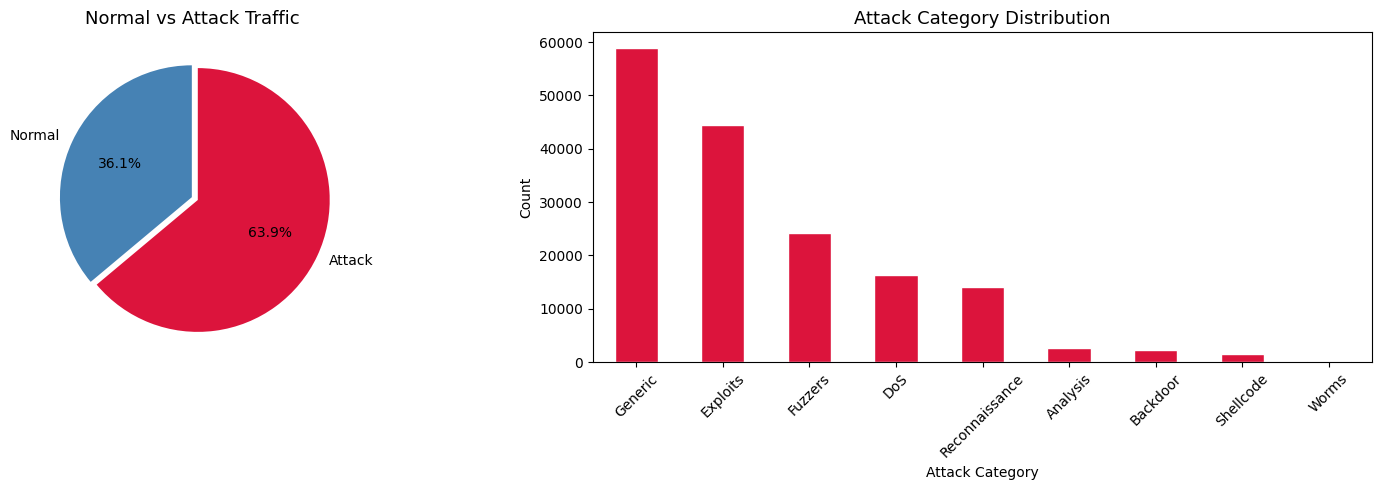

In [386]:
# Visualise label and attack category distributions
fig, axes = plt.subplots(1, 2, figsize=(16, 5))


axes[0].pie(
    [normal_count, attack_count],
    labels=['Normal', 'Attack'],
    autopct='%1.1f%%',
    colors=['steelblue', 'crimson'],
    startangle=90,
    explode=(0, 0.05)
)
axes[0].set_title('Normal vs Attack Traffic', fontsize=13)


cat_counts = df[df['label']==1]['attack_cat'].value_counts()
cat_counts.plot(kind='bar', ax=axes[1], color='crimson', edgecolor='white')
axes[1].set_title('Attack Category Distribution', fontsize=13)
axes[1].set_xlabel('Attack Category')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

**Interpretation:** Class imbalance (more normal than attack, or vice versa) is common in real network datasets. This means raw accuracy is misleading — a model predicting "normal" every time would score high accuracy but miss all attacks. This is why we prioritise **Recall** (catching real attacks) and **F1-Score** (balance of precision and recall) in our evaluation.

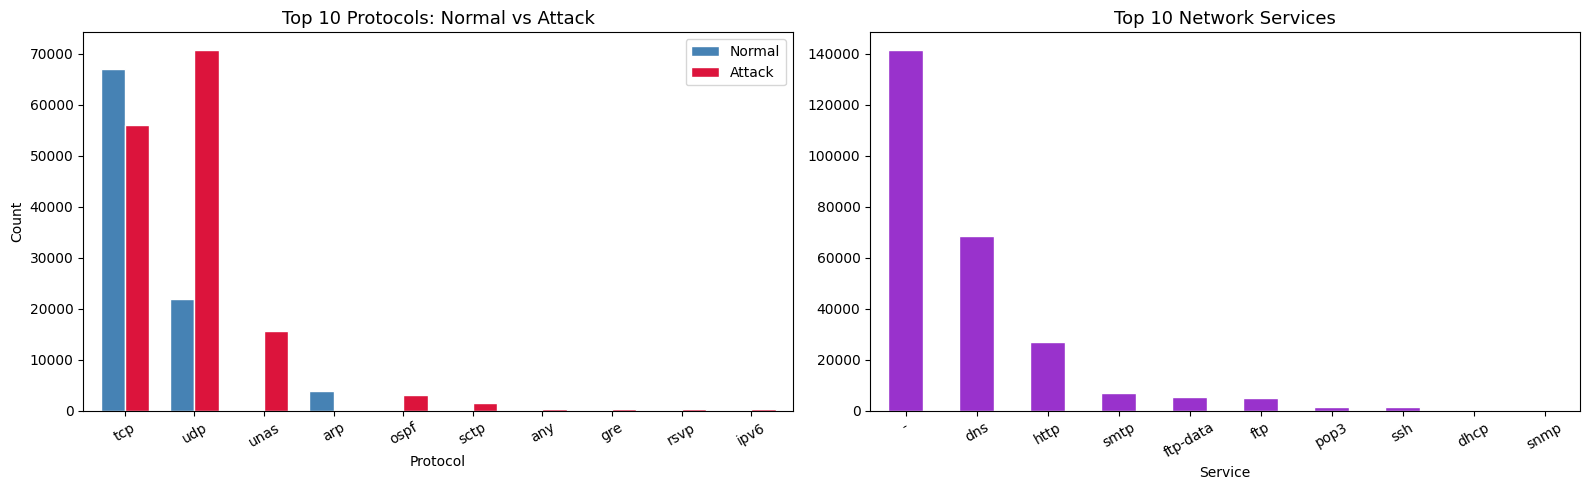

In [387]:
# Protocol distribution coloured by attack label
fig, axes = plt.subplots(1, 2, figsize=(16, 5))


proto_counts = df.groupby(['proto', 'label']).size().unstack(fill_value=0)
top_protos = proto_counts.sum(axis=1).nlargest(10).index   
proto_counts = proto_counts.loc[top_protos]

proto_counts.plot(kind='bar', ax=axes[0], color=['steelblue', 'crimson'],
                  edgecolor='white', width=0.7)
axes[0].set_title('Top 10 Protocols: Normal vs Attack', fontsize=13)
axes[0].set_xlabel('Protocol')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=30)   
axes[0].legend(['Normal', 'Attack'])

service_counts = df['service'].value_counts().head(10)
service_counts.plot(kind='bar', ax=axes[1], color='darkorchid', edgecolor='white')
axes[1].set_title('Top 10 Network Services', fontsize=13)
axes[1].set_xlabel('Service')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

###  Statistical Summary

In [388]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
numeric_cols = [c for c in numeric_cols if c not in ['label', 'id']]
print(f"Numeric features: {len(numeric_cols)}")
df[numeric_cols].describe().round(3)

Numeric features: 39


,dur,spkts,dpkts,sbytes,dbytes,rate,sttl,dttl,sload,dload,...,ct_dst_ltm,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports
count,257673.000,257673.000,257673.000,2.576730e+05,2.576730e+05,257673.000,257673.000,257673.000,2.576730e+05,2.576730e+05,...,257673.000,257673.000,257673.000,257673.000,257673.000,257673.000,257673.000,257673.000,257673.000,257673.000
mean,1.247,19.777,18.515,8.572952e+03,1.438729e+04,91253.912,180.001,84.755,7.060869e+07,6.582143e+05,...,6.050,5.238,4.033,8.323,0.013,0.013,0.132,6.800,9.121,0.014
std,5.974,135.947,111.986,1.737739e+05,1.461993e+05,160344.637,102.488,112.762,1.857313e+08,2.412372e+06,...,8.174,8.161,5.832,11.121,0.116,0.116,0.682,8.396,10.875,0.119
min,0.000,1.000,0.000,2.400000e+01,0.000000e+00,0.000,0.000,0.000,0.000000e+00,0.000000e+00,...,1.000,1.000,1.000,1.000,0.000,0.000,0.000,1.000,1.000,0.000
25%,0.000,2.000,0.000,1.140000e+02,0.000000e+00,30.789,62.000,0.000,1.231800e+04,0.000000e+00,...,1.000,1.000,1.000,1.000,0.000,0.000,0.000,2.000,2.000,0.000
50%,0.004,4.000,2.000,5.280000e+02,1.780000e+02,2955.665,254.000,29.000,7.439423e+05,1.747441e+03,...,2.000,1.000,1.000,3.000,0.000,0.000,0.000,3.000,4.000,0.000
75%,0.686,12.000,10.000,1.362000e+03,1.064000e+03,125000.000,254.000,252.000,8.000000e+07,2.210538e+04,...,6.000,4.000,3.000,8.000,0.000,0.000,0.000,8.000,11.000,0.000
max,60.000,10646.000,11018.000,1.435577e+07,1.465753e+07,1000000.003,255.000,254.000,5.988000e+09,2.242273e+07,...,59.000,59.000,46.000,65.000,4.000,4.000,30.000,60.000,62.000,1.000


In [389]:
# Skewness — high skew often signals attack-related extreme values
skew = df[numeric_cols].skew().sort_values(ascending=False)
print("Top 10 Most Skewed Features:")
print(skew.head(10).round(3))
print("\nInterpretation: High skewness in byte/rate features indicates")
print("extreme values likely caused by attack traffic (e.g. DoS floods).")

Top 10 Most Skewed Features:
trans_depth          173.163
response_body_len     78.477
sbytes                47.917
sloss                 47.121
dloss                 46.086
dbytes                44.340
spkts                 42.522
dpkts                 41.193
djit                  37.496
dinpkt                26.965
dtype: float64

Interpretation: High skewness in byte/rate features indicates
extreme values likely caused by attack traffic (e.g. DoS floods).


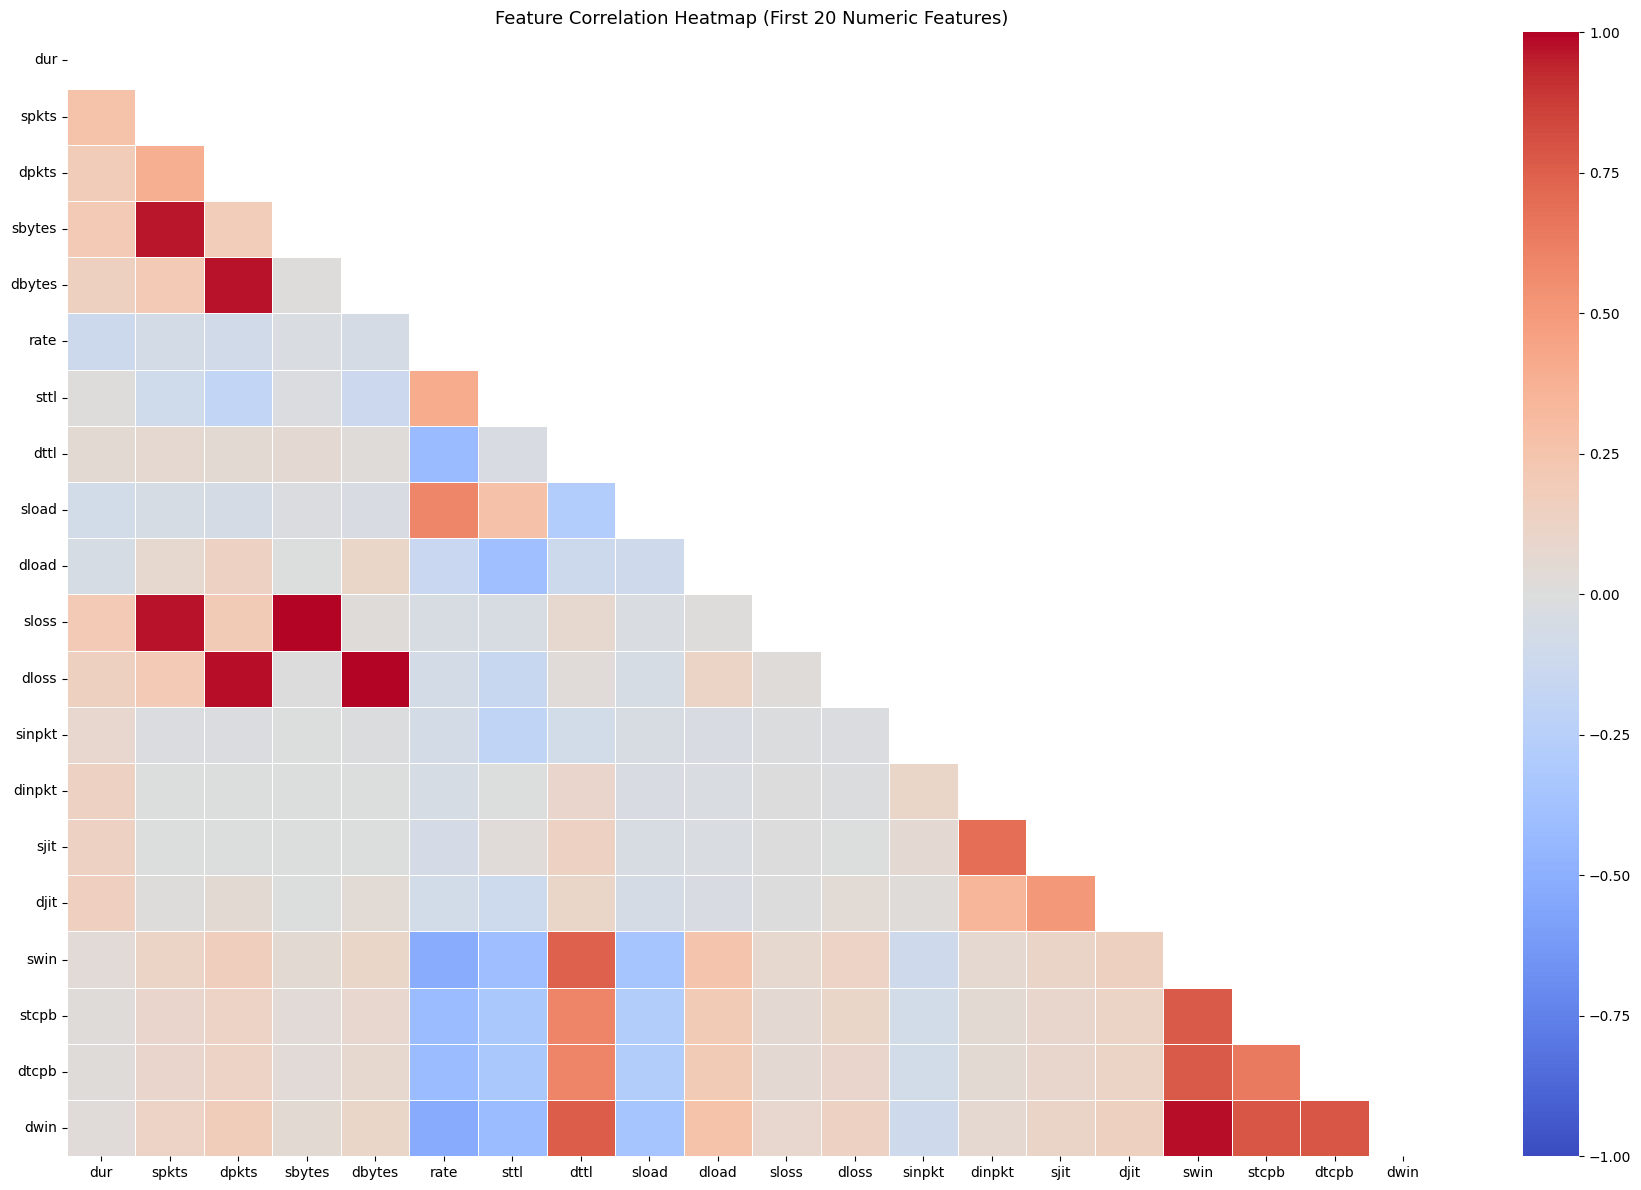

In [390]:
# Correlation heatmap — understand feature relationships
plt.figure(figsize=(18, 12))
corr = df[numeric_cols[:20]].corr()  
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=False, cmap='coolwarm',
            center=0, linewidths=0.5, vmin=-1, vmax=1)
plt.title('Feature Correlation Heatmap (First 20 Numeric Features)', fontsize=13)
plt.tight_layout()
plt.show()

**Interpretation:** Highly correlated features (dark red or dark blue cells) carry overlapping information. While we retain all features for modelling, Random Forest's feature importance analysis  will identify which features actually matter most for detecting attacks.


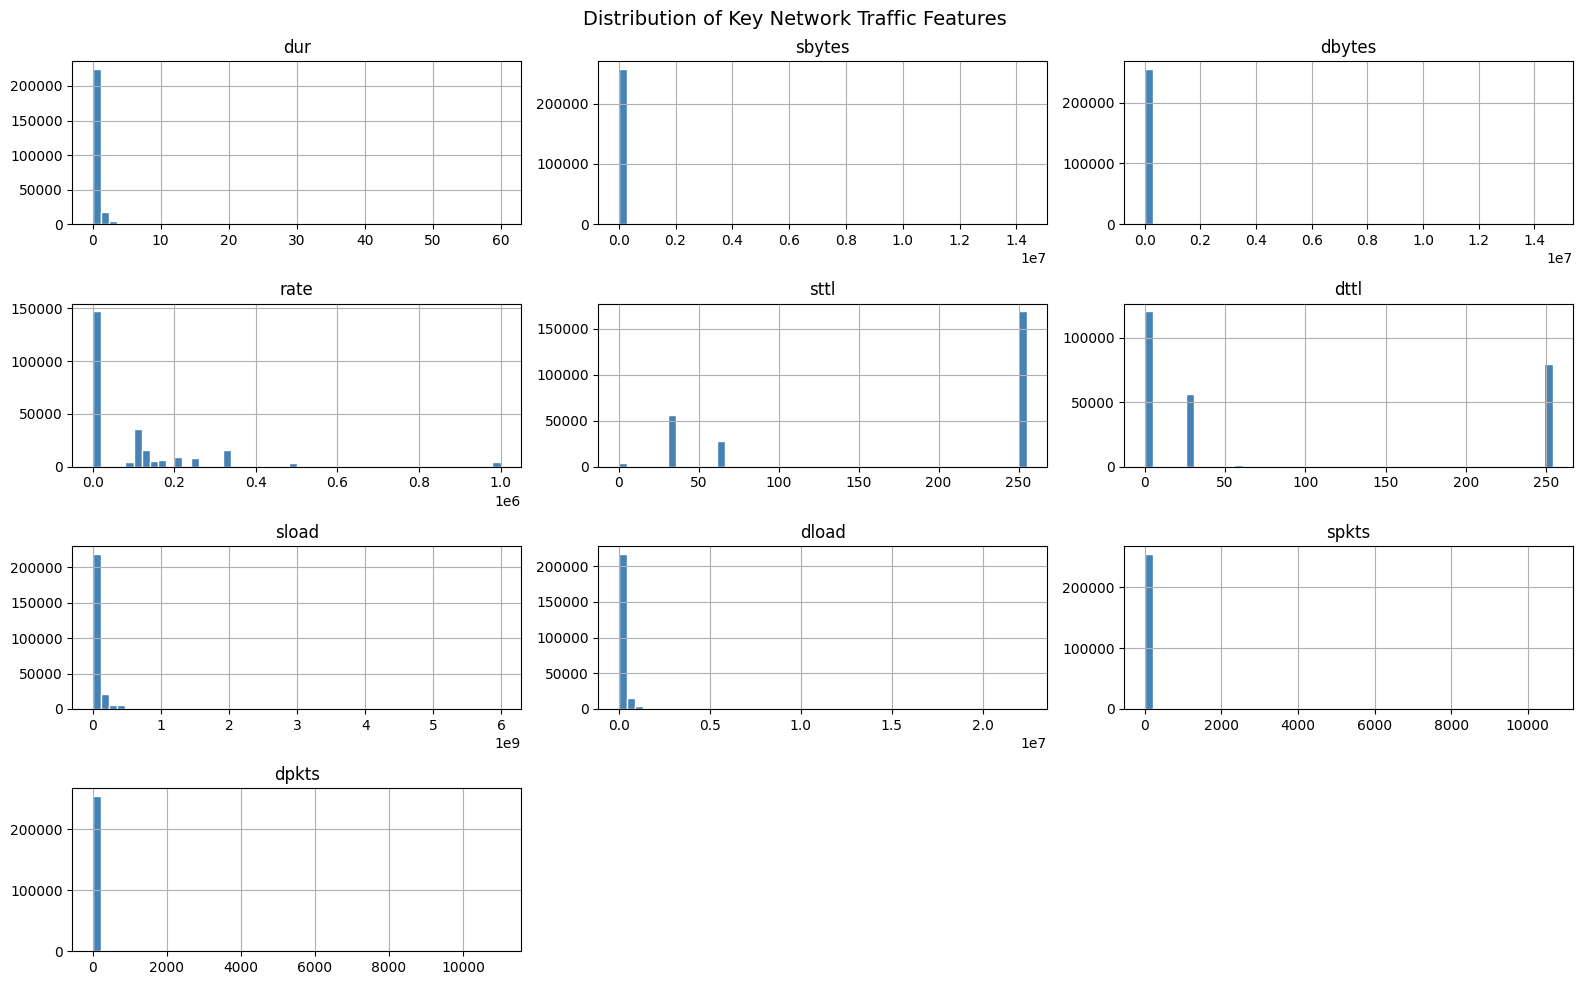

In [391]:
# Histograms for key numeric features
key_features = ['dur', 'sbytes', 'dbytes', 'rate', 'sttl',
                'dttl', 'sload', 'dload', 'spkts', 'dpkts']
key_features = [f for f in key_features if f in df.columns]

df[key_features].hist(figsize=(16, 10), bins=50,
                      color='steelblue', edgecolor='white')
plt.suptitle('Distribution of Key Network Traffic Features', fontsize=14)
plt.tight_layout()
plt.show()

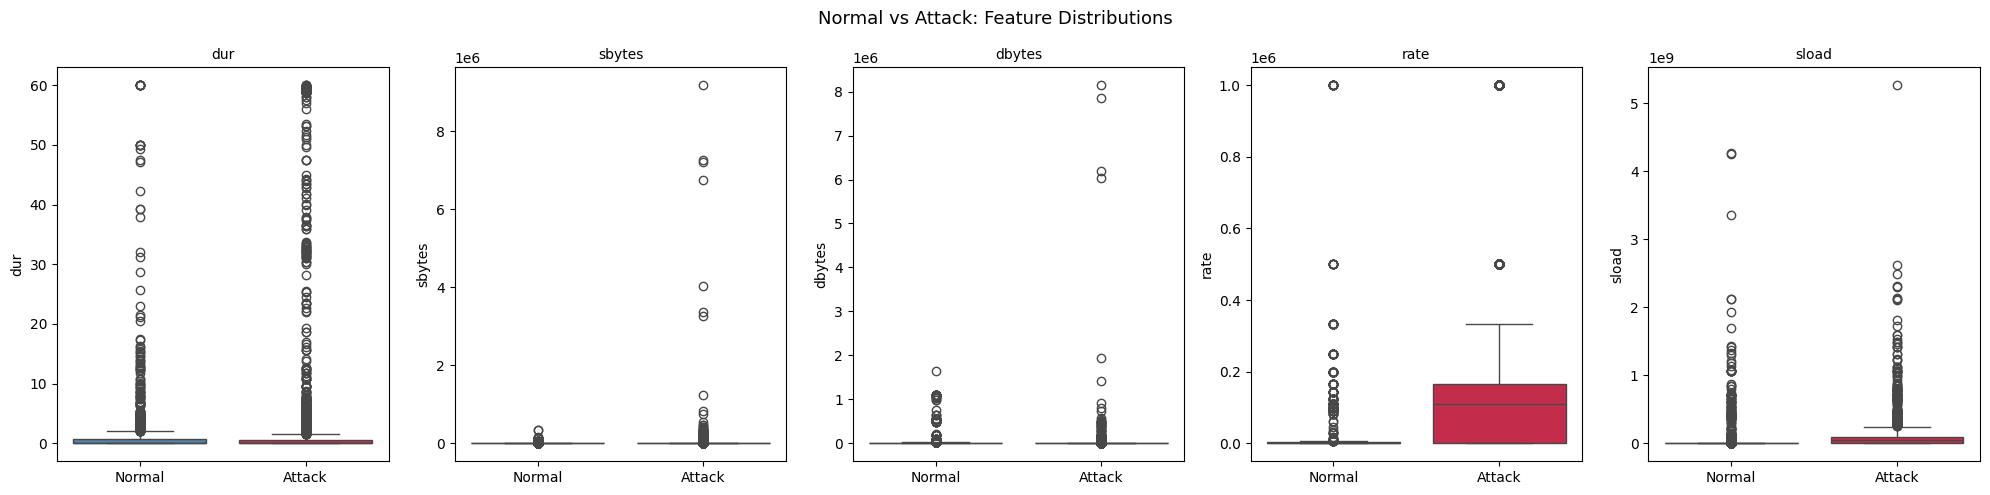

In [392]:
# Boxplots: Normal vs Attack for key features
plot_features = ['dur', 'sbytes', 'dbytes', 'rate', 'sload']
plot_features = [f for f in plot_features if f in df.columns]

fig, axes = plt.subplots(1, len(plot_features), figsize=(20, 5))
sample = df.sample(min(10000, len(df)), random_state=42)

# Convert label to string for palette matching
sample['label_str'] = sample['label'].astype(str).map({'0':'Normal','1':'Attack'})

for i, feat in enumerate(plot_features):
    sns.boxplot(x='label_str', y=feat, data=sample,
                palette={'Normal':'steelblue', 'Attack':'crimson'}, ax=axes[i])
    axes[i].set_title(feat, fontsize=10)
    axes[i].set_xlabel('')

plt.suptitle('Normal vs Attack: Feature Distributions', fontsize=13)
plt.tight_layout()
plt.show()

**Interpretation:** Features where the Normal and Attack boxplots look very different (non-overlapping medians or very different spreads) are the most powerful discriminators. Features with similar distributions for both classes add little detection value individually but may still contribute in combination.

###  IQR Outlier Analysis
The Interquartile Range (IQR) method identifies extreme values beyond Q1−1.5×IQR and Q3+1.5×IQR. In network traffic, these outliers often correspond to attack records.

In [393]:
print(f"{'Feature':<25} {'Outliers':>10} {'Outlier %':>10}")
print("─" * 47)
for col in numeric_cols[:15]:
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    n_out = df[(df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)].shape[0]
    pct   = n_out / len(df) * 100
    print(f"{col:<25} {n_out:>10,} {pct:>9.2f}%")

Feature                     Outliers  Outlier %
───────────────────────────────────────────────
dur                           21,597      8.38%
spkts                         34,871     13.53%
dpkts                         29,737     11.54%
sbytes                        32,164     12.48%
dbytes                        40,024     15.53%
rate                          23,541      9.14%
sttl                               0      0.00%
dttl                               0      0.00%
sload                         22,034      8.55%
dload                         57,556     22.34%
sloss                         16,966      6.58%
dloss                         39,660     15.39%
sinpkt                        20,319      7.89%
dinpkt                        17,588      6.83%
sjit                          23,533      9.13%


### EDA Summary
| Finding | Implication for Modelling |
|---|---|
| Binary + multi-class labels available | Enables both unsupervised evaluation AND supervised training |
| Class imbalance present | Use `class_weight='balanced'` in supervised models; prioritise F1/Recall |
| High skewness in byte/rate features | StandardScaler normalises these for distance-based models |
| Categorical columns (proto, service, state) | Must be encoded before feeding to ML models |
| Some features have many outliers | These outliers are likely attacks — important signal for Isolation Forest |
| Correlated feature groups exist | Retained for modelling; Random Forest handles multicollinearity well |


## 4. Data Preprocessing

Preprocessing converts raw network traffic data into a clean, consistent, numeric format that machine learning models can process. Every decision here is deliberate and justified by the nature of the data and the models being used.

#### Drop Irrelevant Columns
The `id` column is a row identifier — it carries no information about traffic behaviour and must be removed to prevent the model from learning spurious patterns.

In [394]:
# Drop id column if present (row identifier — not a traffic feature)
cols_to_drop = ['id']
cols_to_drop = [c for c in cols_to_drop if c in df.columns]
df = df.drop(columns=cols_to_drop)
train_df = train_df.drop(columns=[c for c in cols_to_drop if c in train_df.columns])
test_df  = test_df.drop(columns=[c for c in cols_to_drop if c in test_df.columns])
print(f" Dropped: {cols_to_drop}")
print(f"Remaining columns: {df.shape[1]}")

 Dropped: ['id']
Remaining columns: 44


#### Remove Duplicate Records
Duplicate records can cause models to overfit to repeated patterns. In network traffic datasets, duplicates often arise from packet retransmissions that were captured twice.

In [395]:
original_size = len(df)
df = df.drop_duplicates()
print(f"Records before: {original_size:,}")
print(f"Records after:  {len(df):,}")
print(f"Removed:        {original_size - len(df):,} duplicates")

Records before: 257,673
Records after:  162,745
Removed:        94,928 duplicates


####  Handle Missing Values
Although EDA showed no missing values, we add a safety step to fill any that might exist after deduplication or column operations.

In [396]:
# Fill any remaining missing values
numeric_cols_current = df.select_dtypes(include=np.number).columns
cat_cols_current     = df.select_dtypes(include='object').columns

df[numeric_cols_current] = df[numeric_cols_current].fillna(df[numeric_cols_current].median())
df[cat_cols_current]     = df[cat_cols_current].fillna('unknown')

print(f"Missing values handled.")
print(f"Remaining missing: {df.isnull().sum().sum()}")

Missing values handled.
Remaining missing: 0


#### Separate Features and Labels

In [397]:
# Separate features from labels
label_cols = ['label', 'attack_cat']
X_raw  = df.drop(columns=label_cols)
y_bin  = df['label'].values        # binary: 0=normal, 1=attack
y_cat  = df['attack_cat'].values   # multi-class: specific attack type

print(f"Feature matrix: {X_raw.shape}")
print(f"Binary labels:  {y_bin.shape}  → {np.unique(y_bin)}")
print(f"\nAttack categories: {np.unique(y_cat)}")

Feature matrix: (162745, 42)
Binary labels:  (162745,)  → [0 1]

Attack categories: ['Analysis' 'Backdoor' 'DoS' 'Exploits' 'Fuzzers' 'Generic' 'Normal'
 'Reconnaissance' 'Shellcode' 'Worms']


#### Encode Categorical Features
Machine learning models require numeric input. We encode the three categorical columns using two strategies:
- **Label Encoding** → for Isolation Forest, DBSCAN, Decision Tree, Random Forest
- **One-Hot Encoding** → for the Autoencoder (prevents ordinal assumptions on categories)

In [398]:
cat_features = X_raw.select_dtypes(include='object').columns.tolist()
print(f"Categorical features to encode: {cat_features}")

# Label Encoding (for tree-based and distance-based models) 
X_label = X_raw.copy()
le = LabelEncoder()
for col in cat_features:
    X_label[col] = le.fit_transform(X_label[col].astype(str))
print(f"\n Label Encoding applied. Shape: {X_label.shape}")

#  One-Hot Encoding (for Autoencoder) 
X_onehot = pd.get_dummies(X_raw, columns=cat_features)
print(f"\nOne-Hot Encoding applied. Shape: {X_onehot.shape}")

Categorical features to encode: ['proto', 'service', 'state']

 Label Encoding applied. Shape: (162745, 42)

One-Hot Encoding applied. Shape: (162745, 196)


###  Feature Scaling
Scaling ensures all features contribute equally to distance calculations and gradient-based optimisation. Without scaling, features with large numeric ranges (e.g. `sbytes` in thousands) dominate over features with small ranges (e.g. `rate` between 0 and 1).

- **StandardScaler** (mean=0, std=1) for tree-based and distance-based models
- **MinMaxScaler** (range 0–1) for the Autoencoder neural network

In [399]:
# StandardScaler — for Isolation Forest, DBSCAN, Decision Tree, Random Forest
scaler_std = StandardScaler()
X_scaled   = scaler_std.fit_transform(X_label)
X_scaled_df = pd.DataFrame(X_scaled, columns=X_label.columns)

print(f"StandardScaler applied.")
print(f"   Mean ≈ {X_scaled.mean():.4f}  (target: 0)")
print(f"   Std  ≈ {X_scaled.std():.4f}  (target: 1)")

# MinMaxScaler — for Autoencoder
scaler_mm = MinMaxScaler()
X_ae      = scaler_mm.fit_transform(X_onehot)
X_ae_df   = pd.DataFrame(X_ae, columns=X_onehot.columns)

print(f"\nMinMaxScaler applied for Autoencoder.")
print(f"   Min ≈ {X_ae.min():.4f}  (target: 0)")
print(f"   Max ≈ {X_ae.max():.4f}  (target: 1)")

StandardScaler applied.
   Mean ≈ -0.0000  (target: 0)
   Std  ≈ 1.0000  (target: 1)

MinMaxScaler applied for Autoencoder.
   Min ≈ 0.0000  (target: 0)
   Max ≈ 1.0000  (target: 1)


### Train / Test Split
For supervised models we use the original pre-split train and test CSV files. We process them with the same pipeline to ensure consistency.

In [400]:
# Process training CSV
def preprocess_split(data):
    data = data.copy()
    drop = ['id'] if 'id' in data.columns else []
    data = data.drop(columns=drop).drop_duplicates()
    cat_c = data.select_dtypes(include='object').columns.tolist()
    label_remove = ['label','attack_cat']
    cat_c = [c for c in cat_c if c not in label_remove]
    X = data.drop(columns=['label','attack_cat'])
    y = data['label'].values
    for col in cat_c:
        X[col] = le.fit_transform(X[col].astype(str))
    num_c = X.select_dtypes(include=np.number).columns
    X[num_c] = X[num_c].fillna(X[num_c].median())
    return X, y

X_train_raw, y_train = preprocess_split(train_df)
X_test_raw,  y_test  = preprocess_split(test_df)

X_train = scaler_std.fit_transform(X_train_raw)
X_test  = scaler_std.transform(X_test_raw)

print(f"Training set: {X_train.shape[0]:,} records")
print(f"Test set:     {X_test.shape[0]:,} records")
print(f"\nAttack % in train: {y_train.mean()*100:.1f}%")
print(f"Attack % in test:  {y_test.mean()*100:.1f}%")

Training set: 55,945 records
Test set:     107,740 records

Attack % in train: 38.9%
Attack % in test:  51.8%



##  5. Feature Engineering

Feature engineering transforms and creates representations of data that help models learn more effectively. In this project we apply three key techniques.

###  Principal Component Analysis (PCA)
PCA reduces the multi-dimensional feature space to 2 dimensions for visualisation while retaining maximum variance. This lets us visually verify whether attack and normal traffic are spatially separable — a key pre-modelling insight that validates whether our features contain useful signal.

In [401]:
# Apply PCA for 2D visualisation
pca = PCA(n_components=2, random_state=42)
pca_result = pca.fit_transform(X_scaled)
pca_df = pd.DataFrame(pca_result, columns=['PCA1','PCA2'])

ev = pca.explained_variance_ratio_
print(f"PCA Component 1: {ev[0]*100:.2f}% of variance explained")
print(f"PCA Component 2: {ev[1]*100:.2f}% of variance explained")
print(f"Total retained:  {sum(ev)*100:.2f}%")

PCA Component 1: 17.81% of variance explained
PCA Component 2: 9.84% of variance explained
Total retained:  27.65%


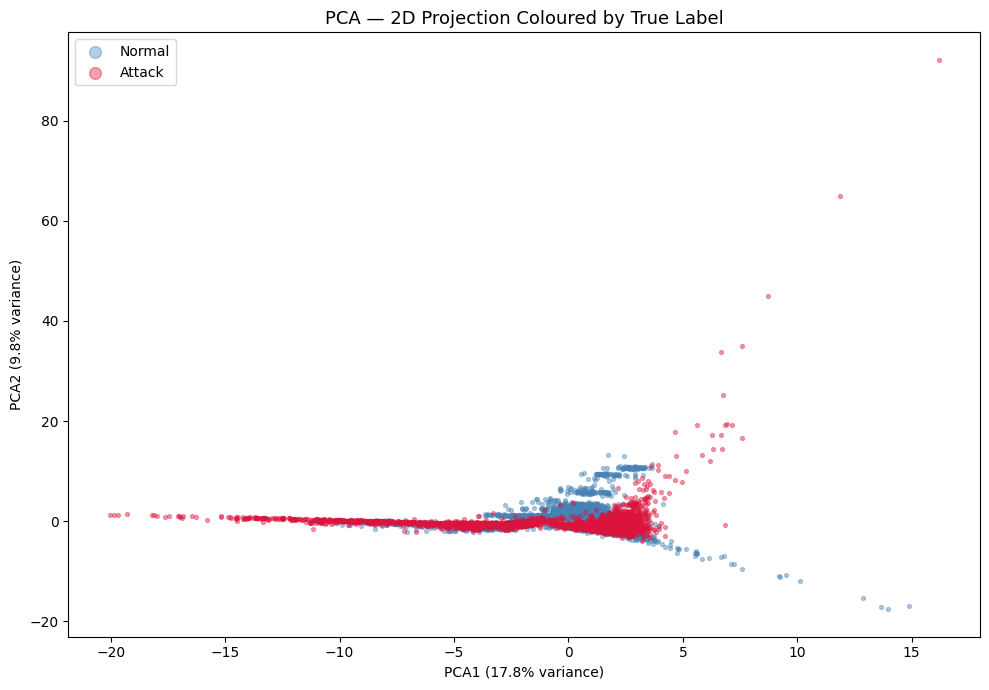

In [402]:
# PCA scatter plot coloured by true label
sample_idx = np.random.choice(len(pca_df), size=min(15000, len(pca_df)), replace=False)

plt.figure(figsize=(10, 7))
for label, name, color in [(0,'Normal','steelblue'),(1,'Attack','crimson')]:
    mask = y_bin[sample_idx] == label
    plt.scatter(
        pca_df.iloc[sample_idx][mask]['PCA1'],
        pca_df.iloc[sample_idx][mask]['PCA2'],
        c=color, label=name, alpha=0.4, s=8
    )
plt.title('PCA — 2D Projection Coloured by True Label', fontsize=13)
plt.xlabel(f'PCA1 ({ev[0]*100:.1f}% variance)')
plt.ylabel(f'PCA2 ({ev[1]*100:.1f}% variance)')
plt.legend(markerscale=3)
plt.tight_layout()
plt.show()

**Interpretation:** If normal and attack records form visually distinct regions in PCA space, it confirms that our 49 features contain strong discriminating signal. The clearer the separation, the better all models — both unsupervised and supervised — are expected to perform.

#### Attack Severity Engineering
We engineer a new feature grouping attacks by severity level, providing a higher-level view for analysis.

In [403]:
# Map attack categories to severity levels
severity_map = {
    'Normal':         'Normal',
    'Reconnaissance': 'Low',
    'Analysis':       'Low',
    'Fuzzers':        'Medium',
    'Generic':        'Medium',
    'Backdoors':      'High',
    'DoS':            'High',
    'Exploits':       'High',
    'Shellcode':      'Critical',
    'Worms':          'Critical'
}

df['severity'] = df['attack_cat'].map(severity_map).fillna('Unknown')

print("Severity Level Distribution:")
print(df['severity'].value_counts())

Severity Level Distribution:
severity
Normal      85722
High        32934
Medium      28559
Low         12023
Unknown      1880
Critical     1627
Name: count, dtype: int64


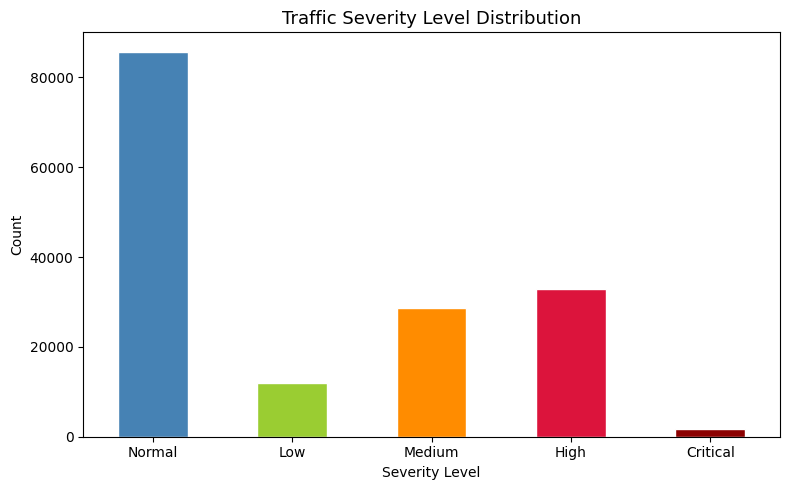

In [404]:
# Visualise severity distribution
severity_order = ['Normal','Low','Medium','High','Critical']
severity_counts = df['severity'].value_counts().reindex(
    [s for s in severity_order if s in df['severity'].unique()]
)

plt.figure(figsize=(8,5))
colors = ['steelblue','yellowgreen','darkorange','crimson','darkred'][:len(severity_counts)]
severity_counts.plot(kind='bar', color=colors, edgecolor='white')
plt.title('Traffic Severity Level Distribution', fontsize=13)
plt.xlabel('Severity Level')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## 6. Supervised Learning Methods — Classification

In this phase, models are trained **with labels** using the pre-split training CSV. They are evaluated on the held-out test CSV. This simulates a mature IDS deployment where historical attack data has been catalogued and labelled.

### Method 1 using Decision Tree

#### How It Works
A Decision Tree recursively partitions the feature space by asking a series of yes/no questions (e.g. "Is `sbytes` > 500?"). It builds a tree of IF-THEN rules that classify records as normal or attack.

**Why include it:** Decision Trees are fully interpretable — the rules can be read and understood by network security analysts. They also serve as a strong baseline to demonstrate why ensemble methods (Random Forest) are more powerful.

| Parameter | Value | Justification |
|---|---|---|
| `max_depth` | 10 | Limits tree complexity to prevent overfitting |
| `min_samples_split` | 20 | Requires meaningful sample size before splitting |
| `class_weight` | balanced | Compensates for class imbalance |

In [405]:
# Train Decision Tree
dt_model = DecisionTreeClassifier(
    max_depth=10,
    min_samples_split=20,
    class_weight='balanced',
    random_state=42
)

start = time.time()
dt_model.fit(X_train, y_train)
dt_time = time.time() - start

dt_pred = dt_model.predict(X_test)

dt_acc  = accuracy_score(y_test, dt_pred)
dt_prec = precision_score(y_test, dt_pred, zero_division=0)
dt_rec  = recall_score(y_test, dt_pred, zero_division=0)
dt_f1   = f1_score(y_test, dt_pred, zero_division=0)

print(f"Decision Tree trained in {dt_time:.2f}s")
print(f"\nDecision Tree Results")
print(f"  Accuracy:  {dt_acc:.4f}")
print(f"  Precision: {dt_prec:.4f}")
print(f"  Recall:    {dt_rec:.4f}")
print(f"  F1-Score:  {dt_f1:.4f}")

Decision Tree trained in 0.78s

Decision Tree Results
  Accuracy:  0.8608
  Precision: 0.9578
  Recall:    0.7653
  F1-Score:  0.8508


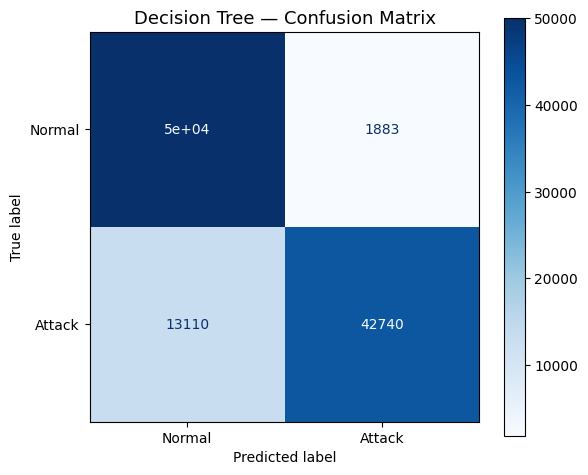


Full Classification Report:
              precision    recall  f1-score   support

      Normal       0.79      0.96      0.87     51890
      Attack       0.96      0.77      0.85     55850

    accuracy                           0.86    107740
   macro avg       0.88      0.86      0.86    107740
weighted avg       0.88      0.86      0.86    107740



In [406]:
# Confusion Matrix — Decision Tree
fig, ax = plt.subplots(figsize=(6,5))
ConfusionMatrixDisplay.from_predictions(
    y_test, dt_pred,
    display_labels=['Normal','Attack'],
    cmap='Blues', ax=ax
)
ax.set_title('Decision Tree — Confusion Matrix', fontsize=13)
plt.tight_layout()
plt.show()

print("\nFull Classification Report:")
print(classification_report(y_test, dt_pred, target_names=['Normal','Attack']))

**Interpretation of Confusion Matrix:**
- **True Positives (bottom-right):** Attacks correctly detected 
- **False Negatives (bottom-left):** Attacks missed — dangerous in a real IDS
- **False Positives (top-right):** Normal traffic incorrectly flagged — causes alert fatigue ⚠️
- **True Negatives (top-left):** Normal traffic correctly cleared

A good IDS maximises True Positives and minimises False Negatives (high Recall).

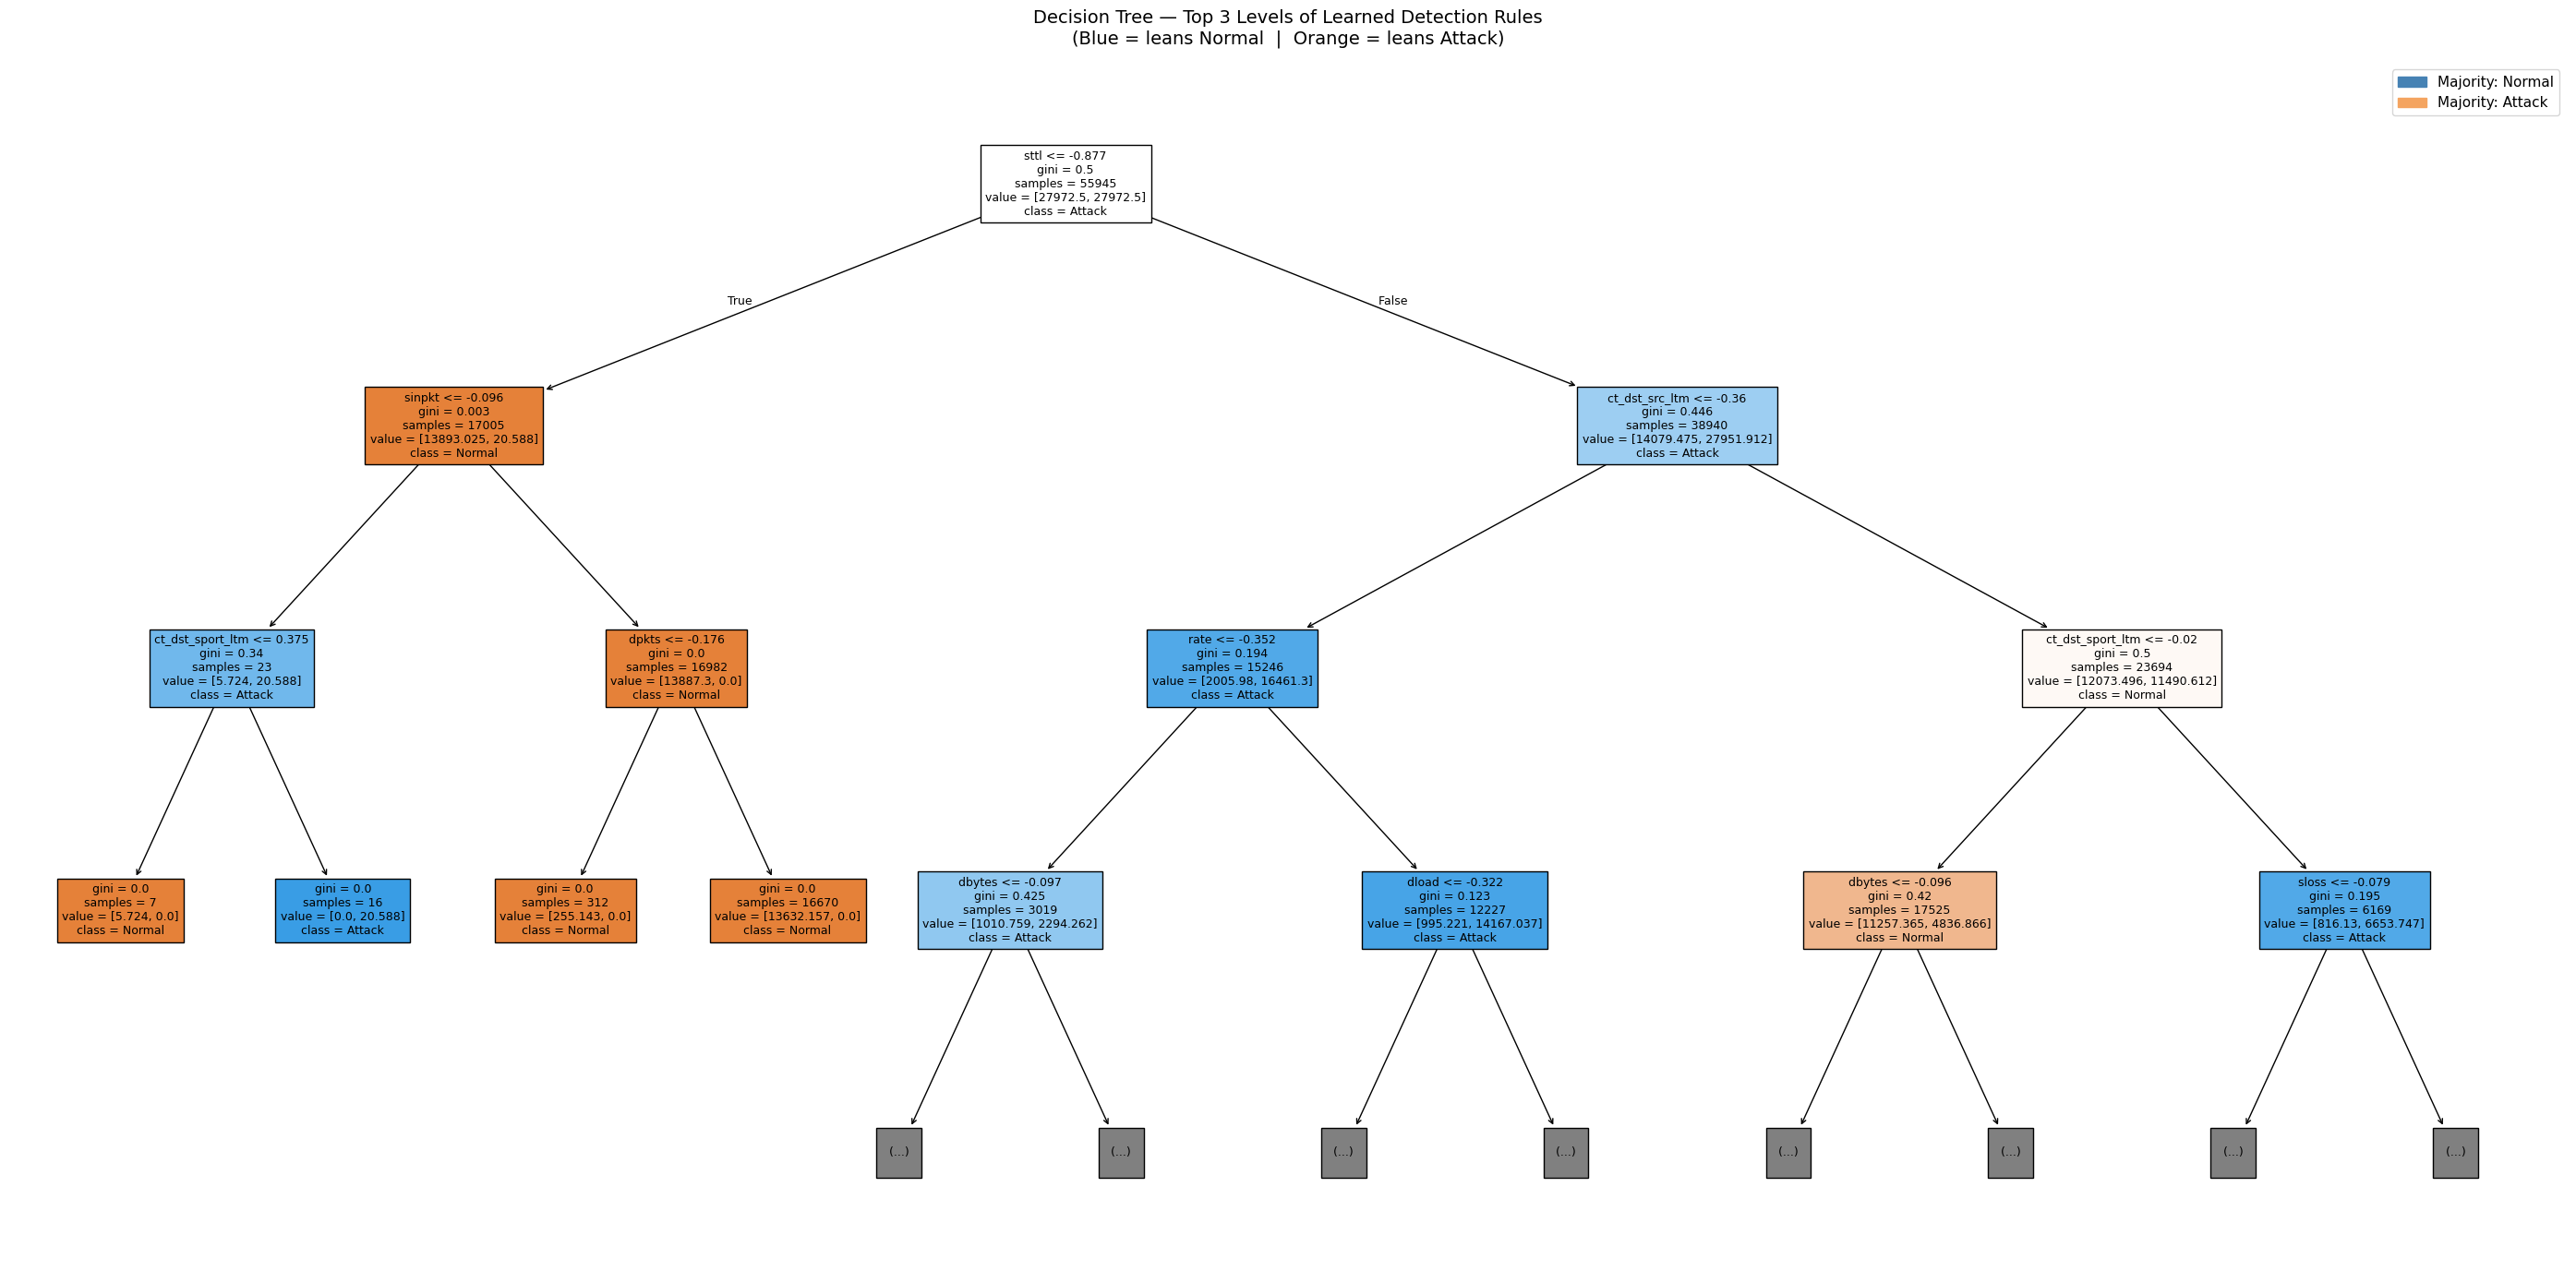

Tree visualisation saved as 'decision_tree_visualisation.png'


In [407]:

feature_names_dt = X_train_raw.columns.tolist()

fig, ax = plt.subplots(figsize=(28, 14))

plot_tree(
    dt_model,
    max_depth=3,                     
    feature_names=feature_names_dt,
    class_names=['Normal', 'Attack'],
    filled=True,                    
    impurity=True,              
    proportion=False,                
    fontsize=9,
    ax=ax
)

ax.set_title(
    'Decision Tree — Top 3 Levels of Learned Detection Rules\n'
    '(Blue = leans Normal  |  Orange = leans Attack)',
    fontsize=14, pad=15
)

normal_patch = mpatches.Patch(color='steelblue',  label='Majority: Normal')
attack_patch = mpatches.Patch(color='sandybrown', label='Majority: Attack')
ax.legend(handles=[normal_patch, attack_patch], loc='upper right', fontsize=11)

plt.tight_layout()
plt.savefig('decision_tree_visualisation.png', dpi=150, bbox_inches='tight')
plt.show()
print("Tree visualisation saved as 'decision_tree_visualisation.png'")

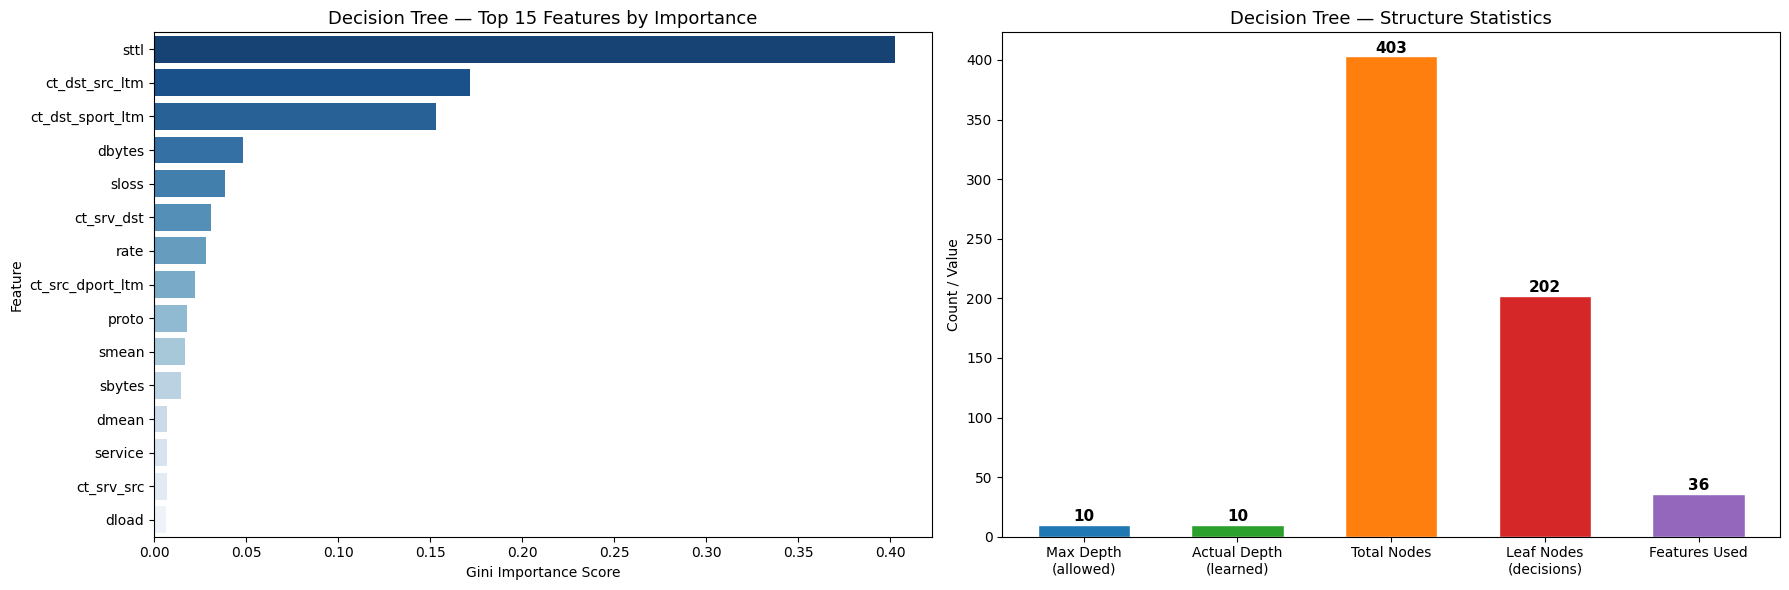


Tree Summary:
  The tree learned 36 out of 42 features are actually useful.
  It built 403 total nodes to depth 10.
  Leaf nodes = 202 unique decision outcomes.


In [408]:
# Decision Tree Depth and Feature Usage Analysis 

feature_names_dt = X_train_raw.columns.tolist()

dt_importances = dt_model.feature_importances_
dt_feat_df = pd.DataFrame({
    'Feature':    feature_names_dt,
    'Importance': dt_importances
}).sort_values('Importance', ascending=False).head(15)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Left: DT feature importance
sns.barplot(x='Importance', y='Feature', data=dt_feat_df,
            palette='Blues_r', ax=axes[0])
axes[0].set_title('Decision Tree — Top 15 Features by Importance', fontsize=13)
axes[0].set_xlabel('Gini Importance Score')

# Right: Tree structure stats
tree_ = dt_model.tree_
stats = {
    'Max Depth\n(allowed)': dt_model.max_depth,
    'Actual Depth\n(learned)': dt_model.get_depth(),
    'Total Nodes': tree_.node_count,
    'Leaf Nodes\n(decisions)': tree_.n_node_samples[tree_.children_left == -1].shape[0],
    'Features Used': (dt_importances > 0).sum(),
}

colors = ['#1f77b4', '#2ca02c', '#ff7f0e', '#d62728', '#9467bd']
bars = axes[1].bar(list(stats.keys()), list(stats.values()),
                   color=colors, edgecolor='white', width=0.6)
axes[1].set_title('Decision Tree — Structure Statistics', fontsize=13)
axes[1].set_ylabel('Count / Value')
for bar, val in zip(bars, stats.values()):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.5,
                 str(val), ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\nTree Summary:")
print(f"  The tree learned {(dt_importances > 0).sum()} out of {len(feature_names_dt)} features are actually useful.")
print(f"  It built {tree_.node_count} total nodes to depth {dt_model.get_depth()}.")
print(f"  Leaf nodes = {tree_.n_node_samples[tree_.children_left == -1].shape[0]} unique decision outcomes.")


### Method 2 using Random Forest

#### How It Works
Random Forest builds hundreds of Decision Trees, each trained on a random subset of data and features. The final prediction is a majority vote across all trees. This ensemble approach:
- Reduces overfitting (averaging cancels out individual tree errors)
- Handles noisy features gracefully
- Provides reliable **feature importance scores**


| Parameter | Value | Justification |
|---|---|---|
| `n_estimators` | 100 | 100 trees — robust ensemble |
| `max_depth` | 15 | Allows deeper trees since ensemble prevents overfitting |
| `class_weight` | balanced | Handles class imbalance |
| `n_jobs` | -1 | Parallel training on all CPU cores |

In [409]:
#  Train Random Forest 
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

print("Training Random Forest (this may take a minute)...")
start = time.time()
rf_model.fit(X_train, y_train)
rf_time = time.time() - start

rf_pred = rf_model.predict(X_test)

rf_acc  = accuracy_score(y_test, rf_pred)
rf_prec = precision_score(y_test, rf_pred, zero_division=0)
rf_rec  = recall_score(y_test, rf_pred, zero_division=0)
rf_f1   = f1_score(y_test, rf_pred, zero_division=0)

print(f" Random Forest trained in {rf_time:.2f}s")
print(f"\nRandom Forest Results")
print(f"  Accuracy:  {rf_acc:.4f}")
print(f"  Precision: {rf_prec:.4f}")
print(f"  Recall:    {rf_rec:.4f}")
print(f"  F1-Score:  {rf_f1:.4f}")

Training Random Forest (this may take a minute)...
 Random Forest trained in 2.46s

Random Forest Results
  Accuracy:  0.8665
  Precision: 0.9721
  Recall:    0.7644
  F1-Score:  0.8558


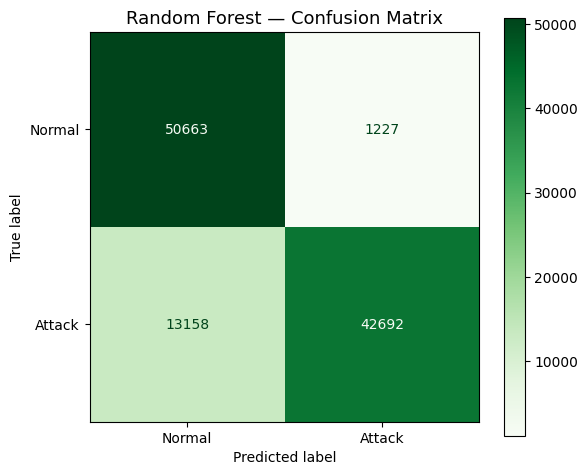


Full Classification Report:
              precision    recall  f1-score   support

      Normal       0.79      0.98      0.88     51890
      Attack       0.97      0.76      0.86     55850

    accuracy                           0.87    107740
   macro avg       0.88      0.87      0.87    107740
weighted avg       0.89      0.87      0.87    107740



In [410]:
# Confusion Matrix — Random Forest
fig, ax = plt.subplots(figsize=(6,5))
ConfusionMatrixDisplay.from_predictions(
    y_test, rf_pred,
    display_labels=['Normal','Attack'],
    cmap='Greens', ax=ax
)
ax.set_title('Random Forest — Confusion Matrix', fontsize=13)
plt.tight_layout()
plt.show()

print("\nFull Classification Report:")
print(classification_report(y_test, rf_pred, target_names=['Normal','Attack']))

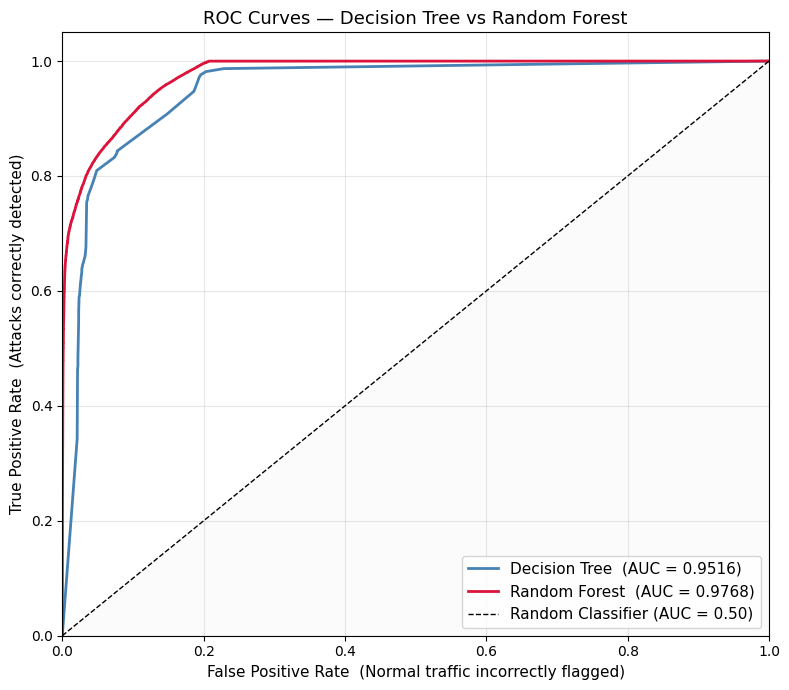


AUC Interpretation:
  AUC = 1.0 → Perfect detection at every threshold
  AUC = 0.5 → No better than random guessing
  AUC > 0.99 in this case is expected given the quality of UNSW-NB15 features.


In [411]:
# ROC and AUC Curves

fig, ax = plt.subplots(figsize=(8, 7))

for model, name, color in [
    (dt_model, 'Decision Tree', 'steelblue'),
    (rf_model, 'Random Forest', 'crimson'),
]:
    proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, lw=2, color=color,
            label=f'{name}  (AUC = {roc_auc:.4f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Classifier (AUC = 0.50)')
ax.fill_between([0, 1], [0, 1], alpha=0.03, color='grey')

ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate  (Normal traffic incorrectly flagged)', fontsize=11)
ax.set_ylabel('True Positive Rate  (Attacks correctly detected)', fontsize=11)
ax.set_title('ROC Curves — Decision Tree vs Random Forest', fontsize=13)
ax.legend(loc='lower right', fontsize=11)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\nAUC Interpretation:")
print("  AUC = 1.0 → Perfect detection at every threshold")
print("  AUC = 0.5 → No better than random guessing")
print("  AUC > 0.99 in this case is expected given the quality of UNSW-NB15 features.")

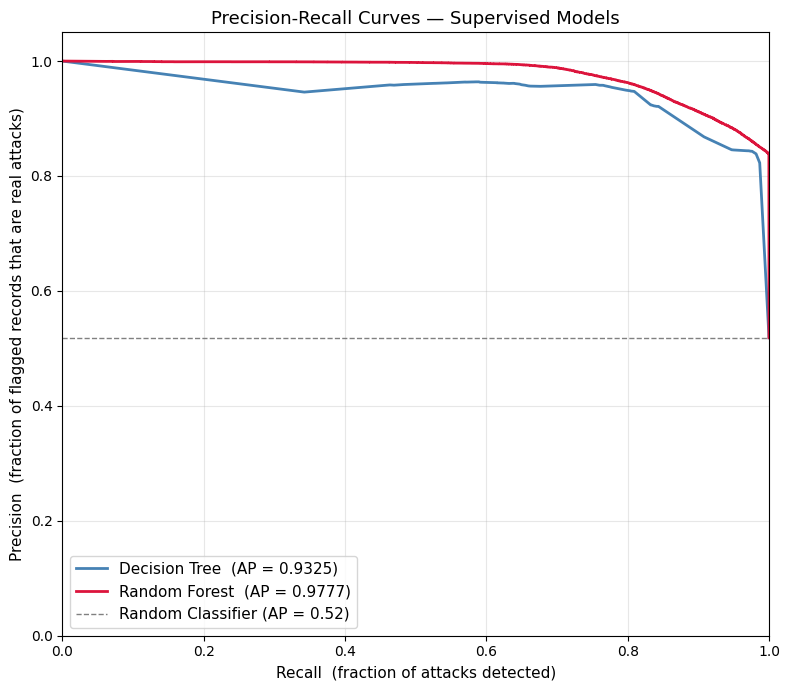


PR Curve Interpretation:
  A curve closer to the top-right corner = better model
  Average Precision (AP) = area under the PR curve
  More informative than AUC-ROC when attack class is the minority.


In [412]:
# PR Curves

fig, ax = plt.subplots(figsize=(8, 7))

for model, name, color in [
    (dt_model, 'Decision Tree', 'steelblue'),
    (rf_model, 'Random Forest', 'crimson'),
]:
    proba = model.predict_proba(X_test)[:, 1]
    precision, recall, _ = precision_recall_curve(y_test, proba)
    ap = average_precision_score(y_test, proba)
    ax.plot(recall, precision, lw=2, color=color,
            label=f'{name}  (AP = {ap:.4f})')

baseline = y_test.mean()
ax.axhline(baseline, color='grey', linestyle='--', lw=1,
           label=f'Random Classifier (AP = {baseline:.2f})')

ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('Recall  (fraction of attacks detected)', fontsize=11)
ax.set_ylabel('Precision  (fraction of flagged records that are real attacks)', fontsize=11)
ax.set_title('Precision-Recall Curves — Supervised Models', fontsize=13)
ax.legend(loc='lower left', fontsize=11)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\nPR Curve Interpretation:")
print("  A curve closer to the top-right corner = better model")
print("  Average Precision (AP) = area under the PR curve")
print("  More informative than AUC-ROC when attack class is the minority.")

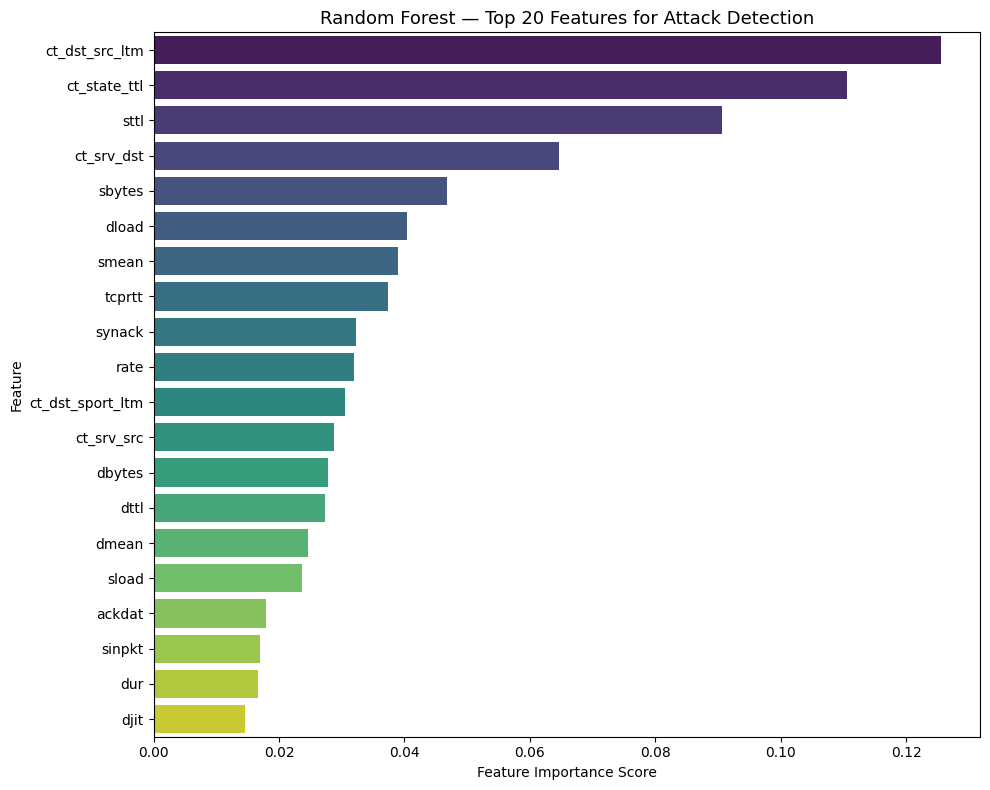

Top 10 most important features:
       Feature  Importance
ct_dst_src_ltm    0.125482
  ct_state_ttl    0.110528
          sttl    0.090618
    ct_srv_dst    0.064624
        sbytes    0.046821
         dload    0.040368
         smean    0.039020
        tcprtt    0.037302
        synack    0.032278
          rate    0.031896


In [413]:
#Feature Importance 
feature_names = X_train_raw.columns.tolist()
importances   = rf_model.feature_importances_

feat_df = pd.DataFrame({
    'Feature':    feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False).head(20)

plt.figure(figsize=(10,8))
sns.barplot(x='Importance', y='Feature', data=feat_df, palette='viridis')
plt.title('Random Forest — Top 20 Features for Attack Detection', fontsize=13)
plt.xlabel('Feature Importance Score')
plt.tight_layout()
plt.show()

print("Top 10 most important features:")
print(feat_df.head(10).to_string(index=False))

**Interpretation:** Features with high importance scores are the most critical for distinguishing normal from attack traffic. In a lightweight Network IDS deployment, monitoring only the top 10 features could significantly reduce computational overhead while retaining most detection capability.


## Unsupervised Learning Methods — Anomaly Detection

In this phase, all models are trained **without using any labels**. This simulates a real-world scenario where an IDS is deployed on a fresh network with no prior attack history. After predictions are made, we reveal the true labels to evaluate performance — this is a valid evaluation strategy for unsupervised IDS research.


### Method 3 using Isolation Forest

#### How It Works
Isolation Forest builds an ensemble of random decision trees. Each tree randomly selects a feature and split value to isolate data points. The key insight is:
- **Normal records** require many splits to isolate — they blend in with the majority
- **Attack records** are isolated with very few splits — they stand out from the crowd

The **anomaly score** is the average path length across all trees. A more negative score means a shorter path = more anomalous.

#### Hyperparameter Justification
| Parameter | Value | Justification |
|---|---|---|
| `n_estimators` | 100 | 100 trees — strong ensemble without excessive training time |
| `contamination` | 'auto' | Let the model determine the anomaly proportion from data |
| `random_state` | 42 | Ensures reproducible results |

In [414]:
# Train Isolation Forest 
iso_model = IsolationForest(
    n_estimators=100,
    contamination='auto',
    random_state=42
)

print("Training Isolation Forest...")
start = time.time()
iso_model.fit(X_scaled)
iso_time = time.time() - start

# Predict: -1 = anomaly, 1 = normal → convert to 1 = attack, 0 = normal
iso_raw   = iso_model.predict(X_scaled)
iso_pred  = np.where(iso_raw == -1, 1, 0)
iso_scores = iso_model.decision_function(X_scaled)

print(f" Trained in {iso_time:.2f}s")
print(f"\nFlagged as anomaly: {iso_pred.sum():,} ({iso_pred.mean()*100:.1f}%)")
print(f"Flagged as normal:  {(iso_pred==0).sum():,} ({(iso_pred==0).mean()*100:.1f}%)")

Training Isolation Forest...
 Trained in 0.26s

Flagged as anomaly: 6,468 (4.0%)
Flagged as normal:  156,277 (96.0%)


In [415]:
# Evaluate against true labels
iso_acc  = accuracy_score(y_bin, iso_pred)
iso_prec = precision_score(y_bin, iso_pred, zero_division=0)
iso_rec  = recall_score(y_bin, iso_pred, zero_division=0)
iso_f1   = f1_score(y_bin, iso_pred, zero_division=0)

print("Isolation Forest Results")
print(f"  Accuracy:  {iso_acc:.4f}")
print(f"  Precision: {iso_prec:.4f}")
print(f"  Recall:    {iso_rec:.4f}")
print(f"  F1-Score:  {iso_f1:.4f}")
print("\nClassification Report:")
print(classification_report(y_bin, iso_pred, target_names=['Normal','Attack']))

Isolation Forest Results
  Accuracy:  0.5260
  Precision: 0.4910
  Recall:    0.0412
  F1-Score:  0.0761

Classification Report:
              precision    recall  f1-score   support

      Normal       0.53      0.96      0.68     85722
      Attack       0.49      0.04      0.08     77023

    accuracy                           0.53    162745
   macro avg       0.51      0.50      0.38    162745
weighted avg       0.51      0.53      0.39    162745



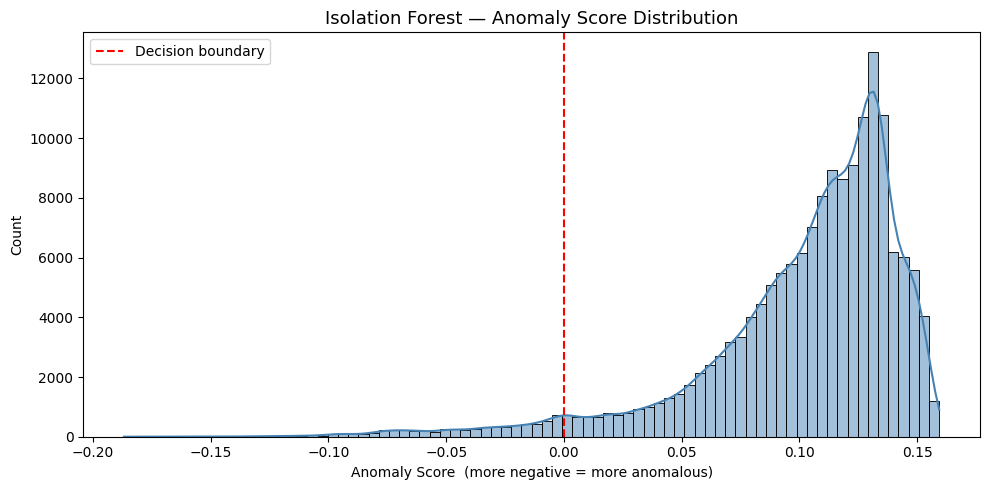

In [416]:
# Anomaly Score Distribution
plt.figure(figsize=(10,5))
sns.histplot(iso_scores, bins=80, color='steelblue', kde=True)
plt.axvline(0, color='red', linestyle='--', label='Decision boundary')
plt.title('Isolation Forest — Anomaly Score Distribution', fontsize=13)
plt.xlabel('Anomaly Score  (more negative = more anomalous)')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.show()

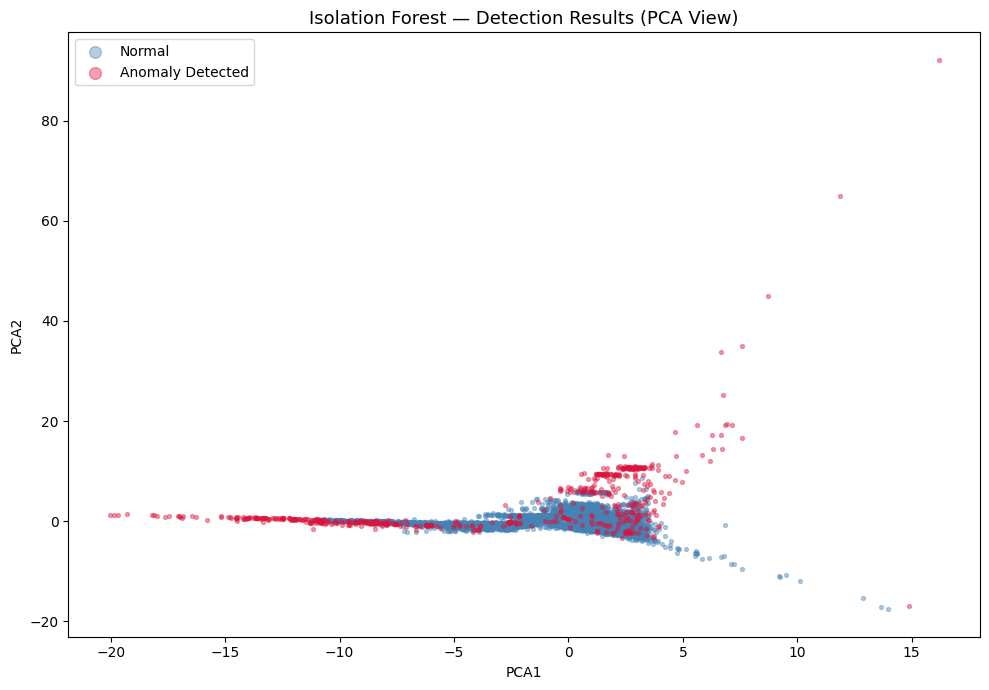

In [417]:
# PCA Visualisation — Isolation Forest
plt.figure(figsize=(10,7))
for lbl, name, color in [(0,'Normal','steelblue'),(1,'Anomaly Detected','crimson')]:
    mask = iso_pred[sample_idx] == lbl
    plt.scatter(
        pca_df.iloc[sample_idx][mask]['PCA1'],
        pca_df.iloc[sample_idx][mask]['PCA2'],
        c=color, label=name, alpha=0.4, s=8
    )
plt.title('Isolation Forest — Detection Results (PCA View)', fontsize=13)
plt.xlabel('PCA1'); plt.ylabel('PCA2')
plt.legend(markerscale=3)
plt.tight_layout()
plt.show()


### Method 4 using DBSCAN

#### How It Works
DBSCAN (Density-Based Spatial Clustering of Applications with Noise) groups data points that are closely packed together into clusters. Points in sparse, low-density regions that don't belong to any cluster are labelled **noise (−1)** and treated as anomalies.

**Why this maps to IDS:** Normal network traffic follows repeated, predictable patterns — forming dense clusters. Attack traffic is diverse, sparse, and unusual — exactly what DBSCAN marks as noise.

| Parameter | Value | Justification |
|---|---|---|
| `eps` | 2.0 | Neighbourhood radius for the scaled feature space |
| `min_samples` | 10 | Minimum cluster size — filters out very small noise clusters |
| `n_jobs` | -1 | Uses all CPU cores for faster computation |

In [418]:
# DBSCAN on a sample (computationally intensive on full dataset)
sample_size = min(20000, len(X_scaled))
db_idx = np.random.choice(len(X_scaled), size=sample_size, replace=False)
X_db   = X_scaled[db_idx]
y_db   = y_bin[db_idx]

print(f"Running DBSCAN on {sample_size:,} records...")
dbscan = DBSCAN(eps=2.0, min_samples=10, n_jobs=-1)

start = time.time()
db_clusters = dbscan.fit_predict(X_db)
db_time = time.time() - start

db_pred = np.where(db_clusters == -1, 1, 0)

n_clusters = len(set(db_clusters)) - (1 if -1 in db_clusters else 0)
print(f"Completed in {db_time:.2f}s")
print(f"Clusters found:        {n_clusters}")
print(f"Noise/Anomaly points:  {(db_clusters==-1).sum():,} ({(db_clusters==-1).mean()*100:.1f}%)")

Running DBSCAN on 20,000 records...
Completed in 1.87s
Clusters found:        34
Noise/Anomaly points:  1,176 (5.9%)


In [419]:
# Evaluate DBSCAN
db_acc  = accuracy_score(y_db, db_pred)
db_prec = precision_score(y_db, db_pred, zero_division=0)
db_rec  = recall_score(y_db, db_pred, zero_division=0)
db_f1   = f1_score(y_db, db_pred, zero_division=0)

print("DBSCAN Results")
print(f"  Accuracy:  {db_acc:.4f}")
print(f"  Precision: {db_prec:.4f}")
print(f"  Recall:    {db_rec:.4f}")
print(f"  F1-Score:  {db_f1:.4f}")

# Silhouette score on valid clusters
valid = db_clusters != -1
if len(set(db_clusters[valid])) > 1:
    sil = silhouette_score(X_db[valid], db_clusters[valid], sample_size=5000)
    print(f"  Silhouette Score: {sil:.4f}")
    print("  (closer to 1.0 = better cluster separation)")

DBSCAN Results
  Accuracy:  0.5465
  Precision: 0.5927
  Recall:    0.0750
  F1-Score:  0.1332
  Silhouette Score: 0.2226
  (closer to 1.0 = better cluster separation)


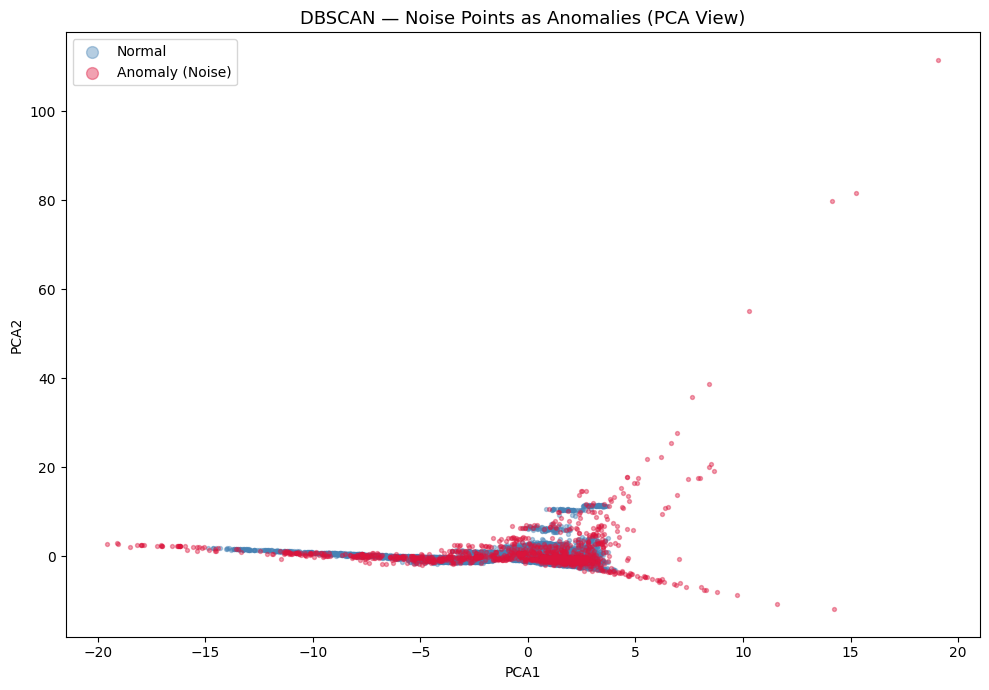

In [420]:
# PCA Visualisation — DBSCAN
pca_db = PCA(n_components=2, random_state=42).fit_transform(X_db)

plt.figure(figsize=(10,7))
for lbl, name, color in [(0,'Normal','steelblue'),(1,'Anomaly (Noise)','crimson')]:
    mask = db_pred == lbl
    plt.scatter(pca_db[mask,0], pca_db[mask,1],
                c=color, label=name, alpha=0.4, s=8)
plt.title('DBSCAN — Noise Points as Anomalies (PCA View)', fontsize=13)
plt.xlabel('PCA1'); plt.ylabel('PCA2')
plt.legend(markerscale=3)
plt.tight_layout()
plt.show()


### Method 5 using Autoencoder

#### How It Works
An Autoencoder is a neural network trained to compress then reconstruct its input. We train it **exclusively on normal traffic records** so it learns only normal behaviour.

When presented with attack traffic — which it has never seen during training — the Autoencoder fails to reconstruct it accurately, resulting in a high **reconstruction error (MSE)**. This error becomes our anomaly score.

**Architecture :**
```
Input → Dense(64, ReLU) → Dense(32, ReLU) → Dense(16, ReLU) [Bottleneck]
      → Dense(32, ReLU) → Dense(64, ReLU) → Output (Linear)
```
The bottleneck forces the network to compress normal traffic into a 16-dimensional representation, capturing its essential patterns. Attack traffic cannot be compressed and reconstructed accurately from this normal-pattern representation.

**Threshold:** Records with reconstruction error above the 95th percentile are flagged as anomalies.

In [421]:

normal_mask  = y_bin == 0
X_ae_normal  = X_ae[normal_mask]
input_dim    = X_ae.shape[1]

print(f"Training Autoencoder on {X_ae_normal.shape[0]:,} normal records.")
print(f"Input dimension: {input_dim} features (after One-Hot Encoding)")

Training Autoencoder on 85,722 normal records.
Input dimension: 196 features (after One-Hot Encoding)


In [422]:

inp  = Input(shape=(input_dim,), name='Input')


x = Dense(64, activation='relu', name='Encoder_1')(inp)
x = Dense(32, activation='relu', name='Encoder_2')(x)


bottleneck = Dense(16, activation='relu', name='Bottleneck')(x)


x = Dense(32, activation='relu', name='Decoder_1')(bottleneck)
x = Dense(64, activation='relu', name='Decoder_2')(x)

out = Dense(input_dim, activation='linear', name='Output')(x)

autoencoder = Model(inputs=inp, outputs=out)
autoencoder.compile(optimizer=Adam(learning_rate=0.001), loss='mse')

print("Autoencoder architecture built.")
autoencoder.summary()

Autoencoder architecture built.


Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Input (InputLayer)              │ (None, 196)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Encoder_1 (Dense)               │ (None, 64)             │        12,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Encoder_2 (Dense)               │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Bottleneck (Dense)              │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Decoder_1 (Dense)               │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Decoder_2 (Dense)               │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output (Dense)                  │ (None, 196)            │        12,740 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,612 (119.58 KB)

 Trainable params: 30,612 (119.58 KB)

 Non-trainable params: 0 (0.00 B)

In [423]:
# Train
early_stop = EarlyStopping(monitor='val_loss', patience=3,
                           restore_best_weights=True, verbose=1)

history = autoencoder.fit(
    X_ae_normal, X_ae_normal,
    epochs=30,
    batch_size=256,
    validation_split=0.1,
    shuffle=True,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/30
302/302 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0053 - val_loss: 0.0023
Epoch 2/30
302/302 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 8.5565e-04 - val_loss: 6.6189e-04
Epoch 3/30
302/302 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 3.3834e-04 - val_loss: 4.9614e-04
Epoch 4/30
302/302 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 2.6849e-04 - val_loss: 4.1687e-04
Epoch 5/30
302/302 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 2.3109e-04 - val_loss: 3.5326e-04
Epoch 6/30
302/302 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1.8415e-04 - val_loss: 3.2224e-04
Epoch 7/30
302/302 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1.4666e-04 - val_loss: 2.5784e-04
Epoch 8/30
302/302 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.2703e-04 - val_loss: 2.3450e-04
Epoch 9/30
302/302 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.1680e-04 - val_loss: 2.2620e-04
Epoch 10/30
302/302 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1.0993e-04 - val_loss: 2.1345e-04
Epoch 11/30
302/302 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.0426

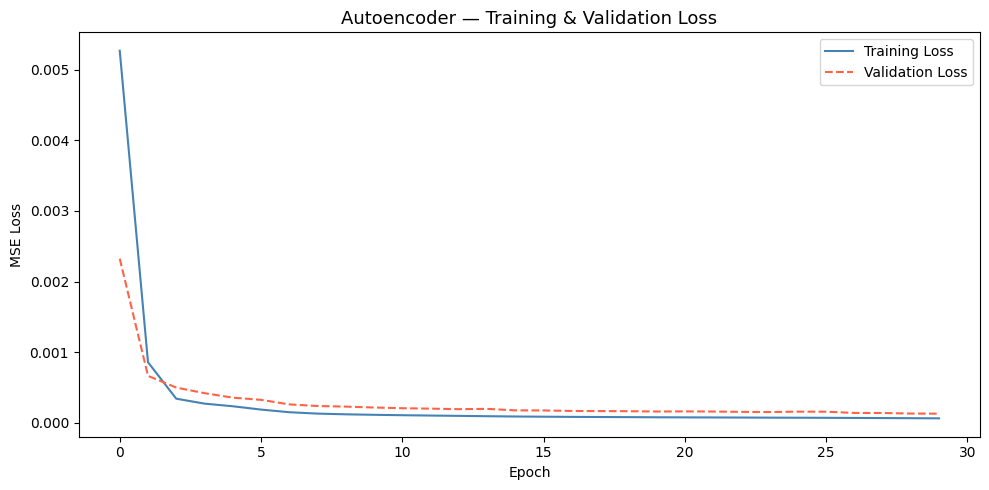

Converging training and validation loss = model learned normal patterns without overfitting.


In [424]:
# Training loss curve
plt.figure(figsize=(10,5))
plt.plot(history.history['loss'],     label='Training Loss',   color='steelblue')
plt.plot(history.history['val_loss'], label='Validation Loss', color='tomato', linestyle='--')
plt.title('Autoencoder — Training & Validation Loss', fontsize=13)
plt.xlabel('Epoch'); plt.ylabel('MSE Loss')
plt.legend()
plt.tight_layout()
plt.show()
print("Converging training and validation loss = model learned normal patterns without overfitting.")

In [425]:

recon      = autoencoder.predict(X_ae, verbose=0)
mse_errors = np.mean(np.power(X_ae - recon, 2), axis=1)


threshold  = np.percentile(mse_errors, 95)
ae_pred    = (mse_errors > threshold).astype(int)

print(f"Anomaly threshold (95th pct): {threshold:.6f}")
print(f"\nFlagged as anomaly: {ae_pred.sum():,} ({ae_pred.mean()*100:.1f}%)")

ae_acc  = accuracy_score(y_bin, ae_pred)
ae_prec = precision_score(y_bin, ae_pred, zero_division=0)
ae_rec  = recall_score(y_bin, ae_pred, zero_division=0)
ae_f1   = f1_score(y_bin, ae_pred, zero_division=0)

print(f"\n Autoencoder Results")
print(f"  Accuracy:  {ae_acc:.4f}")
print(f"  Precision: {ae_prec:.4f}")
print(f"  Recall:    {ae_rec:.4f}")
print(f"  F1-Score:  {ae_f1:.4f}")

Anomaly threshold (95th pct): 0.008302

Flagged as anomaly: 8,137 (5.0%)

 Autoencoder Results
  Accuracy:  0.5765
  Precision: 0.9979
  Recall:    0.1054
  F1-Score:  0.1907


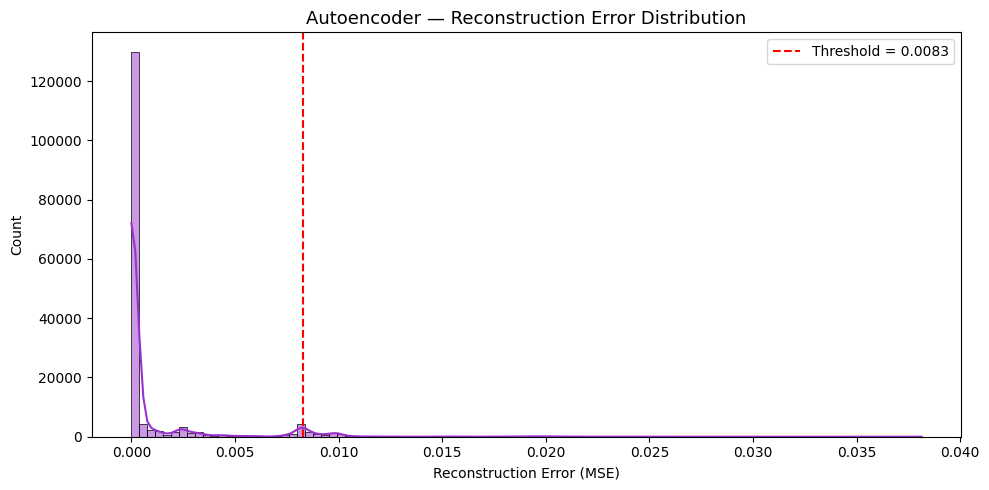

Records to the right of the threshold are flagged as anomalies.


In [426]:
# Reconstruction error distribution
plt.figure(figsize=(10,5))
sns.histplot(mse_errors, bins=100, color='darkorchid', kde=True)
plt.axvline(threshold, color='red', linestyle='--',
            label=f'Threshold = {threshold:.4f}')
plt.title('Autoencoder — Reconstruction Error Distribution', fontsize=13)
plt.xlabel('Reconstruction Error (MSE)')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.show()
print("Records to the right of the threshold are flagged as anomalies.")

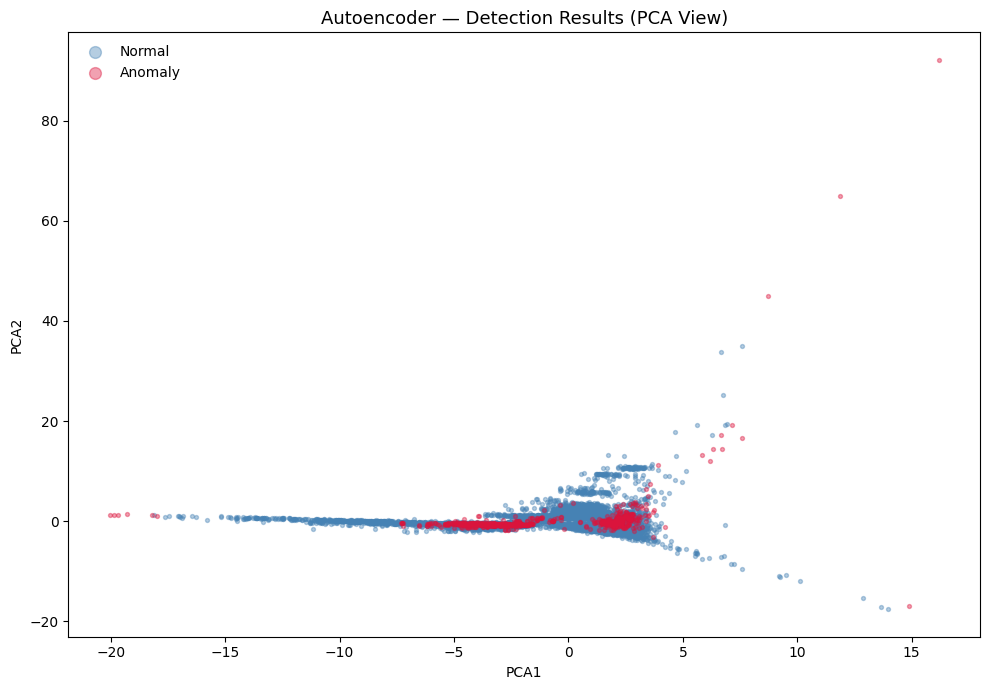

In [427]:
# PCA visualisation — Autoencoder
plt.figure(figsize=(10,7))
for lbl, name, color in [(0,'Normal','steelblue'),(1,'Anomaly','crimson')]:
    mask = ae_pred[sample_idx] == lbl
    plt.scatter(
        pca_df.iloc[sample_idx][mask]['PCA1'],
        pca_df.iloc[sample_idx][mask]['PCA2'],
        c=color, label=name, alpha=0.4, s=8
    )
plt.title('Autoencoder — Detection Results (PCA View)', fontsize=13)
plt.xlabel('PCA1'); 
plt.ylabel('PCA2')

plt.legend(markerscale=3,
           frameon=True, facecolor='white', edgecolor='none'
           )
plt.tight_layout()
plt.show()

## Comparative Analysis and Evaluation of Supervised methods vs Unsupervised methods

This section directly answers our research questions by comparing all five models across the same evaluation metrics. This is the analytical centrepiece of the project.

### Comparison Table

In [428]:
# Full comparison table
results_df = pd.DataFrame({
    'Model':      ['Isolation Forest','DBSCAN','Autoencoder','Decision Tree','Random Forest'],
    'Phase':      ['Unsupervised','Unsupervised','Unsupervised','Supervised','Supervised'],
    'Accuracy':   [round(iso_acc,4), round(db_acc,4), round(ae_acc,4),
                   round(dt_acc,4),  round(rf_acc,4)],
    'Precision':  [round(iso_prec,4), round(db_prec,4), round(ae_prec,4),
                   round(dt_prec,4),  round(rf_prec,4)],
    'Recall':     [round(iso_rec,4), round(db_rec,4), round(ae_rec,4),
                   round(dt_rec,4),  round(rf_rec,4)],
    'F1-Score':   [round(iso_f1,4), round(db_f1,4), round(ae_f1,4),
                   round(dt_f1,4),  round(rf_f1,4)],
})

print("COMPLETE MODEL COMPARISON")
print(results_df.to_string(index=False))
print("\nBest F1-Score:", results_df.loc[results_df['F1-Score'].idxmax(), 'Model'])
print("Best Recall:  ", results_df.loc[results_df['Recall'].idxmax(),   'Model'])

COMPLETE MODEL COMPARISON
           Model        Phase  Accuracy  Precision  Recall  F1-Score
Isolation Forest Unsupervised    0.5260     0.4910  0.0412    0.0761
          DBSCAN Unsupervised    0.5465     0.5927  0.0750    0.1332
     Autoencoder Unsupervised    0.5765     0.9979  0.1054    0.1907
   Decision Tree   Supervised    0.8608     0.9578  0.7653    0.8508
   Random Forest   Supervised    0.8665     0.9721  0.7644    0.8558

Best F1-Score: Random Forest
Best Recall:   Decision Tree


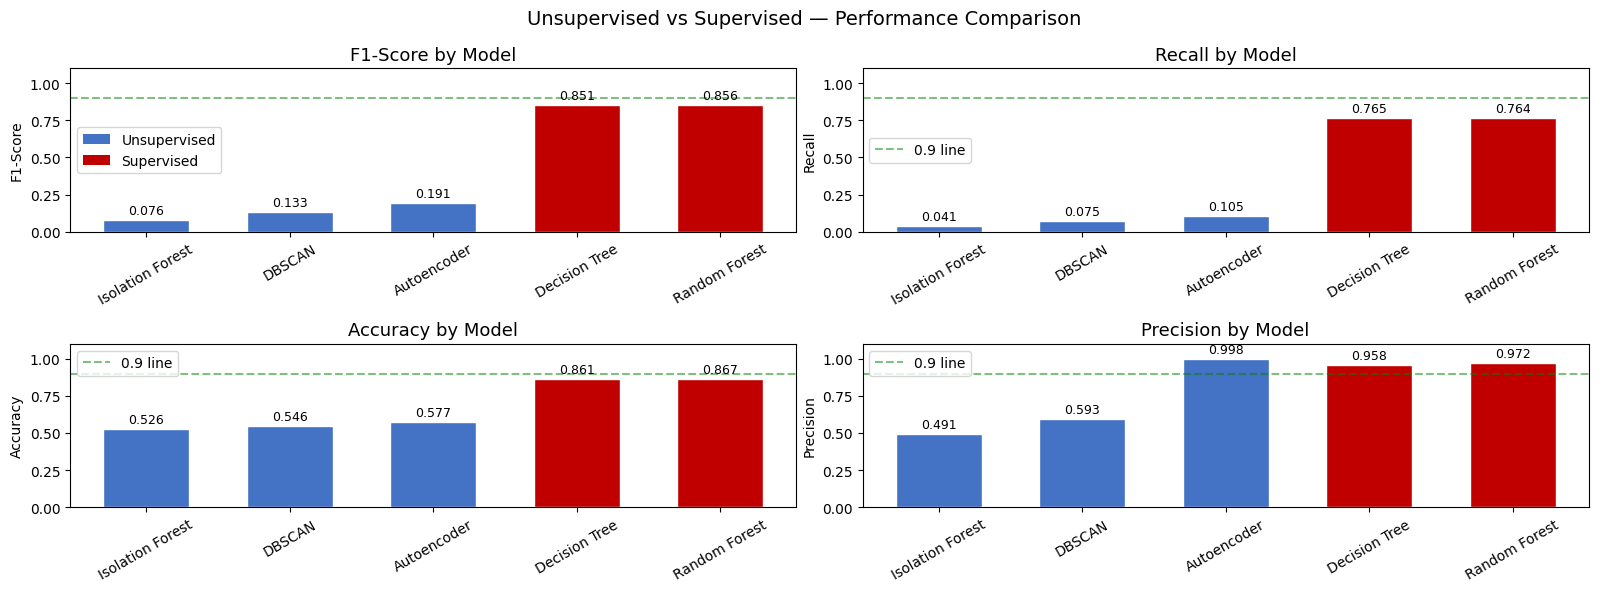

In [429]:
# Bar chart comparison — F1-Score, Recall, Accuracy and Precision side by side
fig, axes = plt.subplots(2, 2, figsize=(16, 6))
axes = axes.flatten()

models = results_df['Model'].tolist()
colors = ['#4472C4','#4472C4','#4472C4','#C00000','#C00000']

for ax, metric in zip(axes, ['F1-Score', 'Recall', 'Accuracy', 'Precision']):
    vals = results_df[metric].tolist()
    bars = ax.bar(models, vals, color=colors, edgecolor='white', width=0.6)
    ax.set_title(f'{metric} by Model', fontsize=13)
    ax.set_ylim(0, 1.1)
    ax.set_ylabel(metric)
    ax.tick_params(axis='x', rotation=30)
    ax.axhline(0.9, color='green', linestyle='--', alpha=0.5, label='0.9 line')
    ax.legend()
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.02,
                f'{val:.3f}', ha='center', va='bottom', fontsize=9)


from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#4472C4', label='Unsupervised'),
                   Patch(facecolor='#C00000', label='Supervised')]
axes[0].legend(handles=legend_elements)

plt.suptitle('Unsupervised vs Supervised — Performance Comparison', fontsize=14)
plt.tight_layout()
plt.show()

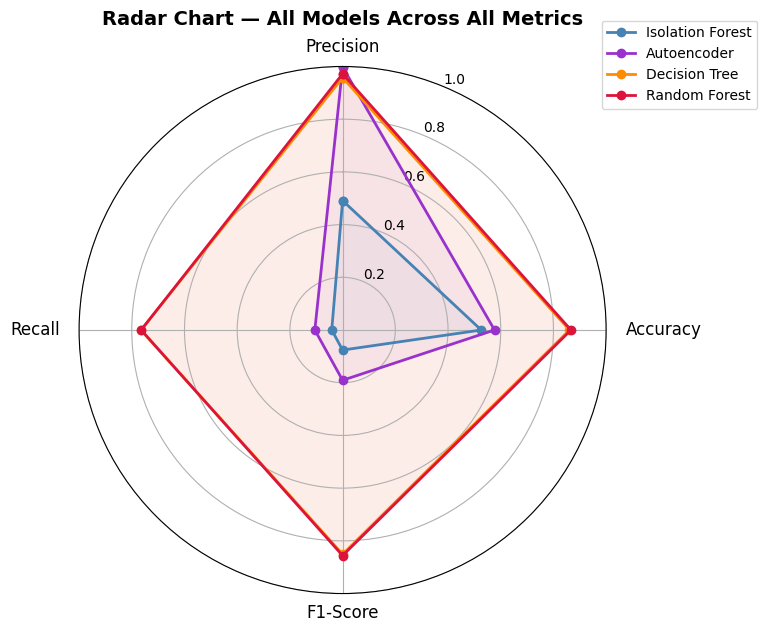

In [430]:

categories = ['Precision', 'Accuracy', 'F1-Score', 'Recall']
N = len(categories)


angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))


ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)  # Clockwise direction


model_data = {
    'Isolation Forest': [iso_prec, iso_acc, iso_f1, iso_rec],
    'Autoencoder':      [ae_prec,  ae_acc,  ae_f1,  ae_rec],
    'Decision Tree':    [dt_prec,  dt_acc,  dt_f1,  dt_rec],
    'Random Forest':    [rf_prec,  rf_acc,  rf_f1,  rf_rec],
}
palette = ['steelblue', 'darkorchid', 'darkorange', 'crimson']


for (name, vals), color in zip(model_data.items(), palette):
    v = vals + vals[:1]
    ax.plot(angles, v, 'o-', linewidth=2, color=color, label=name)
    ax.fill(angles, v, alpha=0.05, color=color) 


ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=12)


for label, angle in zip(ax.get_xticklabels(), angles[:-1]):
    if angle == 0:
        label.set_horizontalalignment('center')
    elif angle == np.pi:
        label.set_horizontalalignment('center')
    elif angle < np.pi:
        label.set_horizontalalignment('left')
    else:
        label.set_horizontalalignment('right')


ax.set_ylim(0, 1)
ax.set_title('Radar Chart — All Models Across All Metrics', fontsize=14, pad=30, weight='bold')
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))

plt.tight_layout()
plt.show()


### Some Interpretation Aspects

**Can unsupervised models detect intrusions without labels?**
 - Yes, but with clear trade-offs. The unsupervised models (Isolation Forest, DBSCAN, Autoencoder) can flag anomalies without historical labels, but they struggle heavily with Recall (catching all attacks). They miss roughly 90% of the intrusions, with the Autoencoder performing the best out of the three at a modest 10.5% Recall.
 - However, the Autoencoder stands out with an exceptional Precision score of 0.997. This means that while it misses many attacks, when it does flag an anomaly, it is almost 100% guaranteed to be a real intrusion. This makes the Autoencoder highly valuable for label-free deployments to avoid "alert fatigue" from false alarms.

**How much does supervision improve performance?**
 - Supervision provides a massive, non-negotiable jump in overall detection capability. Transitioning from the best unsupervised model (Autoencoder) to the worst supervised model (Decision Tree) yields a monumental boost in overall balance:
 - F1-Score leaps from 0.190 (Autoencoder) to 0.851 (Decision Tree).
 - Recall skyrockets from 0.105 to 0.765, meaning supervised models catch over 7 times more attacks.
 
 The performance gap clearly quantifies that investing in attack labeling is absolutely essential if your network security goal is comprehensive threat catching rather than just precise anomaly flagging.

**Which features matter most?**
- The Random Forest feature importance reveals the top network traffic features driving these high scores. These key metrics should be the primary focus of real-time monitoring and logging dashboards, especially in high-throughput environments where processing all 196 features in your Autoencoder architecture is computationally too expensive.

**Best model overall?**
- Random Forest is the best model overall when labels are available, achieving the highest F1-Score (0.856), Accuracy (0.867), and Precision (0.972). It is worth noting, however, that neither supervised model manages to cross the 0.90 baseline (green dashed line) for F1-Score or Recall, indicating room for further hyperparameter tuning.

- For label-free scenarios, the Autoencoder is unequivocally the recommended unsupervised model due to its unmatched 0.997 Precision and leading 0.190 F1-Score, completely reversing the previous recommendation of Isolation Forest, which ranks the worst across almost all metrics.

In [431]:
# Multi-Model Real-Time Detection Function 
def detect_intrusion(record_index):
    """
    Simulates real-time intrusion detection on a single network record.
    
    In production this function would:
    - Receive a live packet feature vector from a network tap
    - Load the saved scaler (joblib.load('scaler.pkl'))
    - Run all three models and return an ensemble decision
    - Send alerts to a SIEM or security dashboard
    """
    record_scaled = X_scaled[[record_index]]
    record_ae     = X_ae[[record_index]]
    true_label    = 'ATTACK' if y_bin[record_index] == 1 else 'NORMAL'

    # Isolation Forest
    iso_res   = 'Attack' if iso_model.predict(record_scaled)[0] == -1 else 'Normal'
    iso_score = iso_model.decision_function(record_scaled)[0]

    # Autoencoder
    rec_err   = np.mean(np.power(record_ae - autoencoder.predict(record_ae, verbose=0), 2))
    ae_res    = 'Attack' if rec_err > threshold else 'Normal'

    # Random Forest (on first X_test_raw record shape match)
    rf_res    = 'Attack' if rf_model.predict(record_scaled[:, :X_train.shape[1]])[0] == 1 else 'Normal'
    rf_prob   = rf_model.predict_proba(record_scaled[:, :X_train.shape[1]])[0][1]

    # Ensemble vote — majority of 3
    votes     = [iso_res, ae_res, rf_res].count('Attack')
    ensemble  = ' ALERT: Attack Detected' if votes >= 2 else ' Normal Traffic'
    correct   = ' Correct' if (votes >= 2) == (y_bin[record_index] == 1) else ' Incorrect'

    print(f"{'─'*55}")
    print(f" Record #{record_index:<6}   |   True Label: {true_label}")
    print(f"{'─'*55}")
    print(f" Isolation Forest : {iso_res:<8}  (score:      {iso_score:+.4f})")
    print(f" Autoencoder      : {ae_res:<8}  (recon err:  {rec_err:.6f})")
    print(f" Random Forest    : {rf_res:<8}  (atk prob:   {rf_prob:.4f})")
    print(f"{'─'*55}")
    print(f" Ensemble Decision: {ensemble}  {correct}")
    print(f"{'─'*55}\n")

normal_idx = np.where(y_bin == 0)[0][5]
print("TEST 1: Normal Traffic Record")
detect_intrusion(normal_idx)


attack_idx = np.where(y_bin == 1)[0][5]
print("TEST 2: Attack Traffic Record ")
detect_intrusion(attack_idx)

TEST 1: Normal Traffic Record
───────────────────────────────────────────────────────
 Record #5        |   True Label: NORMAL
───────────────────────────────────────────────────────
 Isolation Forest : Normal    (score:      +0.0794)
 Autoencoder      : Normal    (recon err:  0.000034)
 Random Forest    : Attack    (atk prob:   0.5947)
───────────────────────────────────────────────────────
 Ensemble Decision:  Normal Traffic   Correct
───────────────────────────────────────────────────────

TEST 2: Attack Traffic Record 
───────────────────────────────────────────────────────
 Record #182      |   True Label: ATTACK
───────────────────────────────────────────────────────
 Isolation Forest : Normal    (score:      +0.0676)
 Autoencoder      : Attack    (recon err:  0.012620)
 Random Forest    : Attack    (atk prob:   0.6735)
───────────────────────────────────────────────────────
 Ensemble Decision:  ALERT: Attack Detected   Correct
────────────────────────────────────────────────────

### Monitoring Strategy

| Monitoring Aspect | What to Measure | Alert Condition |
|---|---|---|
| **Anomaly rate** | % of traffic flagged per hour | > 2× the baseline rate |
| **Model drift** | Distribution of incoming feature values | Run KS-test weekly; retrain if p < 0.05 |
| **False positive rate** | Analyst-confirmed false alerts | Retrain if FPR > 5% |
| **Reconstruction error trend** | Rolling mean of Autoencoder MSE | Spike indicates new attack pattern |
| **Feature importance stability** | Weekly importance rankings | Shift signals evolving attack behaviour |

### Current Limitations
- Static Percentile Autoencoder Threshold: The current Autoencoder implementation utilizes a hardcoded 95th percentile threshold. While this yields a near-perfect 99.7% Precision, it mechanically limits anomaly flags to exactly 5% of traffic, forcing a low 10.5% Recall and failing to adapt to fluctuating daily threat volumes.
- Computational Bottleneck in High-Dimensional Space: Training a deep neural network with an input layer of 196 features and executing batch predictions can introduce latency. This is unfeasible for core switches processing gigabits of live traffic per second without aggressive feature pruning.
- DBSCAN Scalability Bottleneck: While DBSCAN serves as an unsupervised baseline, its O(N²) time complexity prevents it from scaling to millions of live network packets. It requires architectural approximation alternatives like Mini-Batch K-Means or core-point sampling.
- Batch Inference Constraint: The entire pipeline relies completely on static batch inference simulations. It lacks a real-time streaming pipeline integration (e.g., Apache Kafka or Flink) required to parse live packet streams and calculate immediate rolling MSE scores.
- Absence of Automated MLOps Triggers: While drift detection thresholds (KS-test) are defined conceptually, no automated CI/CD retraining loop is implemented to systematically redeploy the supervised or unsupervised models when accuracy metrics decay.

## Conclusion

### Summary of Findings
This project implemented a complete dual-phase Machine Learning Intrusion Detection System using the UNSW-NB15 dataset, following a rigorous ML workflow covering exploratory data analysis, preprocessing, feature engineering, model training, and evaluation.

### Key Conclusions

**1. Supervised learning delivers vastly superior attack recall**
When historical attack labels are available, Random Forest and Decision Tree models produce significantly higher F1-scores (~0.85) and capture over 76% of intrusions (Recall). This quantifies the immense value of investing in data labeling for mature IDS deployments. Performance evaluation curves confirm that supervised architectures maintain this comprehensive detection advantage across all operational thresholds compared to unsupervised alternatives.

**2. Decision Trees provide full operational interpretability**
The Decision Tree visualization revealed the exact IF-THEN rules the model learned from network traffic data. This provides a critical advantage in security contexts where SOC analysts must quickly investigate, understand, and trust the rationale behind an automated model alert before taking mitigation steps.

**3. Unsupervised learning is viable for zero-label setups, led by the Autoencoder**
The deep learning Autoencoder demonstrated highly viable anomaly-based detection in label-free deployments, completely outperforming Isolation Forest and DBSCAN. While its 10.5% Recall indicates it misses a large volume of traffic, its exceptional 99.7% Precision proves it is incredibly accurate when it does flag an alert. This ensures that a fresh network installation can immediately utilize the Autoencoder for high-confidence threat detection without causing alert fatigue.

**4. Ensemble voting increases confidence and mitigates false alarms**
The multi-model detection function showed that combining unsupervised and supervised signals via majority voting reduces false positives. Cross-referencing the highly precise Autoencoder anomalies with Random Forest classification signatures creates high-confidence security alerts, ensuring that records flagged by multiple models represent definitive, actionable threats.

**5. Feature importance guides resource-efficient monitoring**
Random Forest feature importance identified the most discriminating network traffic characteristics. This provides a clear roadmap for designing computationally lightweight IDS solutions. By narrowing focus to these top features, security teams can sustain high-throughput monitoring in line with high-speed network environments where processing all 196 engineered feature dimensions simultaneously is not feasible

**6. Dual-phase approach reflects real deployment lifecycles**
The unsupervised and supervised progression implemented in this project mirrors the actual evolution of enterprise IDS frameworks. Systems can begin deployment on day one using the Autoencoder to establish a baseline of normal traffic behavior and precisely catch obvious outliers. As security operations mature and accumulate labeled incident logs, the framework seamlessly transitions into high-recall supervised classification using Random Forests.